# Large-N Runtime Performance Benchmarks


## Large-N Runtime Toggle
These benchmarks now support the dedicated `large_n` runtime path. Set `GPU_DEVICE = "9"` and `RUNTIME_PATH = "large_n"` below for the new path, and uses the canonical large_n runtime path.

In [1]:
import os
GPU_DEVICE = "1"
RUNTIME_PATH = "large_n"
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_DEVICE
print(f"CUDA_VISIBLE_DEVICES={GPU_DEVICE}, RUNTIME_PATH={RUNTIME_PATH}")

def inject_runtime_path(kwargs):
    updated = dict(kwargs)
    updated["runtime_path"] = RUNTIME_PATH
    return updated


CUDA_VISIBLE_DEVICES=1, RUNTIME_PATH=large_n


## Goals

- Measure runtime scaling with particle count for the large-N solver path.
- Break `prepare_state` and steady-state evaluation into comparable runtime components.
- Compare runtime-relevant execution choices such as far-field layout, near-field mode, MAC, and prepare micro-profile contributions.


In [2]:
import os

# --- Option A: automatic GPU selection with autocvd ---
USE_AUTOCVD = False
AUTOCVD_NUM_GPUS = 1
AUTOCVD_LEAST_USED = True
AUTOCVD_EXCLUDE = []

# --- Option B: manual selection (set to string like '0' or '0,1') ---
MANUAL_CUDA_VISIBLE_DEVICES = GPU_DEVICE  # None #"1,2,3,4,5,6,7,8,9"#None

if MANUAL_CUDA_VISIBLE_DEVICES is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = MANUAL_CUDA_VISIBLE_DEVICES
    print("Set CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])
elif USE_AUTOCVD:
    try:
        from autocvd import autocvd

        autocvd(
            num_gpus=AUTOCVD_NUM_GPUS,
            least_used=AUTOCVD_LEAST_USED,
            exclude=AUTOCVD_EXCLUDE,
        )
        print(
            "autocvd selected CUDA_VISIBLE_DEVICES =",
            os.environ.get("CUDA_VISIBLE_DEVICES"),
        )
    except ImportError:
        print(
            "autocvd is not installed. Install it or set MANUAL_CUDA_VISIBLE_DEVICES."
        )
else:
    print(
        "Using existing CUDA visibility:",
        os.environ.get("CUDA_VISIBLE_DEVICES", "<all visible>"),
    )

# Index precision switch (must be set before importing JAX/jaccpot/yggdrax).
INDEX_PRECISION = "int32"  # choose from: "int32", "int64"
os.environ.setdefault("JACCPOT_INDEX_PRECISION", INDEX_PRECISION)
os.environ.setdefault("YGGDRAX_INDEX_PRECISION", INDEX_PRECISION)
print("Index precision:", os.environ.get("JACCPOT_INDEX_PRECISION"))

# GPU memory-fragmentation / graph-memory safeguards.
os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_ALLOCATOR", "platform")
os.environ.setdefault("JACCPOT_PREPARE_DIAGNOSTICS", "1")
os.environ.setdefault("YGGDRAX_TRAVERSAL_DIAGNOSTICS", "1")
if "--xla_gpu_enable_command_buffer=" not in os.environ.get("XLA_FLAGS", ""):
    existing_xla_flags = os.environ.get("XLA_FLAGS", "").strip()
    command_buffer_off = "--xla_gpu_enable_command_buffer="
    os.environ["XLA_FLAGS"] = (
        f"{existing_xla_flags} {command_buffer_off}".strip()
        if existing_xla_flags
        else command_buffer_off
    )

# Runtime cache limits (reduce transient cache memory pressure for capacity runs).
os.environ.setdefault("JACCPOT_OPERATOR_CACHE_MAX", "256")
os.environ.setdefault("JACCPOT_GROUPED_OPERATOR_CACHE_MAX", "16")
os.environ.setdefault("JACCPOT_GROUPED_SEGMENT_CACHE_MAX", "16")
os.environ.setdefault(
    "JACCPOT_GROUPED_OPERATOR_CACHE_ENTRY_MAX_BYTES", str(16 * 1024 * 1024)
)
os.environ.setdefault(
    "JACCPOT_GROUPED_OPERATOR_CACHE_TOTAL_MAX_BYTES", str(64 * 1024 * 1024)
)
os.environ.setdefault(
    "JACCPOT_GROUPED_SEGMENT_CACHE_ENTRY_MAX_BYTES", str(8 * 1024 * 1024)
)
os.environ.setdefault(
    "JACCPOT_GROUPED_SEGMENT_CACHE_TOTAL_MAX_BYTES", str(32 * 1024 * 1024)
)
print(
    "Runtime cache limits:",
    {
        "op_max": os.environ.get("JACCPOT_OPERATOR_CACHE_MAX"),
        "grp_op_max": os.environ.get("JACCPOT_GROUPED_OPERATOR_CACHE_MAX"),
        "grp_seg_max": os.environ.get("JACCPOT_GROUPED_SEGMENT_CACHE_MAX"),
        "grp_op_total_mb": int(
            os.environ.get("JACCPOT_GROUPED_OPERATOR_CACHE_TOTAL_MAX_BYTES", "0")
        )
        // (1024 * 1024),
        "grp_seg_total_mb": int(
            os.environ.get("JACCPOT_GROUPED_SEGMENT_CACHE_TOTAL_MAX_BYTES", "0")
        )
        // (1024 * 1024),
    },
)

VISIBLE_PHYSICAL_GPUS = [
    part.strip()
    for part in os.environ.get("CUDA_VISIBLE_DEVICES", "").split(",")
    if part.strip() != ""
]
NVIDIA_SMI_GPU_INDEX = int(VISIBLE_PHYSICAL_GPUS[0]) if VISIBLE_PHYSICAL_GPUS else 0
print("JACCPOT_PREPARE_DIAGNOSTICS:", os.environ.get("JACCPOT_PREPARE_DIAGNOSTICS"))
print("YGGDRAX_TRAVERSAL_DIAGNOSTICS:", os.environ.get("YGGDRAX_TRAVERSAL_DIAGNOSTICS"))
print("nvidia-smi physical GPU index:", NVIDIA_SMI_GPU_INDEX)

Set CUDA_VISIBLE_DEVICES = 1
Index precision: int32
Runtime cache limits: {'op_max': '256', 'grp_op_max': '16', 'grp_seg_max': '16', 'grp_op_total_mb': 64, 'grp_seg_total_mb': 32}
JACCPOT_PREPARE_DIAGNOSTICS: 1
YGGDRAX_TRAVERSAL_DIAGNOSTICS: 1
nvidia-smi physical GPU index: 1


In [3]:
import pathlib
import sys
from dataclasses import replace

import jax

# Force float64 in accuracy sweeps; otherwise JAX may silently downcast to float32.
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = pathlib.Path.cwd().resolve()
if not (REPO_ROOT / "jaccpot").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from jaccpot import (
    FMMAdvancedConfig,
    FMMPreset,
    FarFieldConfig,
    FastMultipoleMethod,
    NearFieldConfig,
    RuntimePolicyConfig,
    TreeConfig,
 )
from yggdrax import Tree, compute_tree_geometry
from yggdrax.interactions import DualTreeTraversalConfig, build_interactions_and_neighbors
from examples import benchmark_utils as bench_utils

#plt.style.use("seaborn-v0_8-darkgrid")
import inspect

In [4]:
import inspect
import jaccpot
import jaccpot.runtime._fmm_impl as jf
import yggdrax
import yggdrax._interactions_impl as yi

print("jaccpot:", jaccpot.__file__)
print("yggdrax:", yggdrax.__file__)

src_j = inspect.getsource(jf.FastMultipoleMethod._resolve_runtime_execution_overrides)
print("streamed/grouped guard:", "if self.streamed_far_pairs and grouped_interactions" in src_j)
print("minimum-memory traversal None:", "traversal_config = None" in src_j)

src_y = inspect.getsource(yi)
print("count-pass fill cap:", "_COUNT_PASS_FILL_INTERACTION_CAP = 4096" in src_y)


jaccpot: /export/home/tbuck/jaccpot/jaccpot/__init__.py
yggdrax: /export/home/tbuck/yggdrax/yggdrax/__init__.py
streamed/grouped guard: True
minimum-memory traversal None: False
count-pass fill cap: True


## Benchmark configuration

Adjust the parameters below to control sweep ranges, repetition counts, and floating-point precision.

In [5]:
runtime_particle_counts = [
    512,
    1024,
    2048,
    4096,
    8192,
    16384,
    32768,
    65536,
    131072,
    262144,
    524288,
    1048576,
    2097152,
    4194304,
    8388608,
    16777216
 ]
runtime_leaf_size = 256
runtime_max_order = 4
runtime_runs = 3
runtime_warmup = 1
runtime_isolate_process_per_n = True
runtime_worker_benchmark_scope = "full"
runtime_worker_autotune_cache_path = REPO_ROOT / "benchmarks" / "runtime_accuracy_worker_autotune_cache.json"

# Radix fast-lane benchmark profiles (canonical production path).
runtime_fast_lane_compare_enabled = True
runtime_fast_lane_default_block_size = 8
runtime_main_sweep_lane_label = "fast_lane"

runtime_lane_profiles = [
    {
        "lane_label": "baseline",
        "target_block_size": 0,
        "env": {
            "YGGDRAX_NEARFIELD_TARGET_BLOCK_SIZE": "0",
            "JACCPOT_LARGE_N_TARGET_BLOCK_SIZE": "0",
        },
    },
    {
        "lane_label": "fast_lane",
        "target_block_size": int(runtime_fast_lane_default_block_size),
        "env": {
            "YGGDRAX_NEARFIELD_TARGET_BLOCK_SIZE": str(int(runtime_fast_lane_default_block_size)),
            "JACCPOT_LARGE_N_TARGET_BLOCK_SIZE": str(int(runtime_fast_lane_default_block_size)),
        },
    },
]

runtime_lane_profile_map = {str(p["lane_label"]): p for p in runtime_lane_profiles}
if str(runtime_main_sweep_lane_label) not in runtime_lane_profile_map:
    raise ValueError(
        f"unknown runtime_main_sweep_lane_label={runtime_main_sweep_lane_label!r}; "
        f"expected one of {sorted(runtime_lane_profile_map)}"
    )
runtime_main_sweep_lane = runtime_lane_profile_map[str(runtime_main_sweep_lane_label)]
runtime_main_sweep_target_block_size = int(runtime_main_sweep_lane["target_block_size"])
for _env_key, _env_value in runtime_main_sweep_lane.get("env", {}).items():
    os.environ[str(_env_key)] = str(_env_value)
print(
    "Main runtime sweep lane:",
    runtime_main_sweep_lane_label,
    "target_block_size=",
    runtime_main_sweep_target_block_size,
)
print(
    "active env:",
    {
        "YGGDRAX_NEARFIELD_TARGET_BLOCK_SIZE": os.environ.get("YGGDRAX_NEARFIELD_TARGET_BLOCK_SIZE", ""),
        "JACCPOT_LARGE_N_TARGET_BLOCK_SIZE": os.environ.get("JACCPOT_LARGE_N_TARGET_BLOCK_SIZE", ""),
    },
)

accuracy_particle_count = 4096  # keep direct reference tractable
accuracy_leaf_size = 256
accuracy_orders = [1, 2, 3, 4]
accuracy_thetas = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9]

# New: order-only accuracy sweep at fixed θ (clean scaling curve)
order_sweep_particle_count = 4096
order_sweep_leaf_size = 256
order_sweep_orders = list(range(1, 9))
order_sweep_theta = 0.4
order_sweep_mac_type = "dehnen"

softening = 1e-3
runtime_working_dtype = jnp.float32
accuracy_working_dtype = jnp.float64  # tighten accuracy sweep floor
runtime_key = jax.random.PRNGKey(0)
accuracy_key = jax.random.PRNGKey(1)
order_diag_key = jax.random.PRNGKey(2)

# Lean large-N runtime baseline aligned with the production H100/H200 sweep.
runtime_mac_type = "engblom"
runtime_memory_first_m2l_chunk_size = 1024


def _round_up_pow2(value, *, min_value, max_value):
    value = max(int(min_value), int(value))
    value = 1 << (value - 1).bit_length()
    return int(min(int(max_value), value))


def runtime_traversal_seed_for_num_particles(num_particles):
    n = int(num_particles)
    if n <= 4194304 and n > 2097152:
        return dict(
            max_pair_queue=4194304,
            process_block=512,
            max_interactions_per_node=65536,
            max_neighbors_per_leaf=65536,
        )
    scale = max(1.0, float(n) / 524288.0)
    queue = _round_up_pow2(scale * 262144, min_value=65536, max_value=33554432)
    interactions = _round_up_pow2(scale * 8192, min_value=4096, max_value=131072)
    neighbors = _round_up_pow2(scale * 4096, min_value=1024, max_value=131072)
    if n >= 2097152:
        interactions = max(interactions, 32768)
        neighbors = max(neighbors, 32768)
    if n >= 8388608:
        interactions = max(interactions, 65536)
        neighbors = max(neighbors, 65536)
    if n <= 131072:
        process_block = 64
    elif n <= 524288:
        process_block = 128 if queue <= 131072 else 256
    elif n <= 4194304:
        process_block = 512 if queue >= 2097152 else 256
    else:
        process_block = 1024 if queue >= 4194304 else 512
    return dict(
        max_pair_queue=int(queue),
        process_block=int(process_block),
        max_interactions_per_node=int(interactions),
        max_neighbors_per_leaf=int(neighbors),
    )


runtime_baseline_num_particles = 1048576
runtime_baseline_traversal = runtime_traversal_seed_for_num_particles(runtime_baseline_num_particles)
BEST_TRAVERSAL_CONFIG = None

runtime_advanced = FMMAdvancedConfig(
    tree=TreeConfig(
        tree_type="radix",
        mode="lbvh",
        leaf_target=runtime_leaf_size,
        refine_local=False,
        max_refine_levels=0,
        aspect_threshold=16.0,
    ),
    farfield=FarFieldConfig(
        rotation="solidfmm",
        mode="pair_grouped",
        grouped_interactions=False,
        streamed_far_pairs=True,
        m2l_chunk_size=int(runtime_memory_first_m2l_chunk_size),
    ),
    nearfield=NearFieldConfig(
        # Fast-lane path requires bucketed nearfield; keep fixed across the N sweep.
        mode="bucketed",
        edge_chunk_size=128,
        precompute_scatter_schedules=False,
    ),
    runtime=RuntimePolicyConfig(
        host_refine_mode="off",
        fail_fast=True,
        jit_tree=True,
        jit_traversal=True,
        memory_objective="minimum_memory",
        max_pair_queue=None,
        pair_process_block=None,
        traversal_config=None,
        enable_interaction_cache=False,
        retain_traversal_result=False,
        retain_interactions=False,
        autotune_m2l_chunk=False,
        upward_leaf_batch_size=2048,
    ),
    mac_type=runtime_mac_type,
)
runtime_fmm_kwargs = dict(
    preset=FMMPreset.LARGE_N_GPU,
    basis="solidfmm",
    theta=0.6,
    softening=softening,
    working_dtype=runtime_working_dtype,
    advanced=runtime_advanced,
)

accuracy_advanced = FMMAdvancedConfig(
    tree=TreeConfig(leaf_target=accuracy_leaf_size),
    farfield=FarFieldConfig(
        rotation="solidfmm",
        mode="pair_grouped",
        grouped_interactions=True,
        m2l_chunk_size=int(runtime_memory_first_m2l_chunk_size),
    ),
    nearfield=NearFieldConfig(mode="bucketed", edge_chunk_size=128),
    runtime=RuntimePolicyConfig(
        max_pair_queue=262144,
        pair_process_block=256,
        traversal_config=None,
    ),
    mac_type="dehnen",
)
accuracy_fmm_kwargs = dict(
    preset=FMMPreset.BALANCED,
    basis="solidfmm",
    theta=0.6,
    softening=softening,
    working_dtype=accuracy_working_dtype,
    advanced=accuracy_advanced,
)


def override_fmm_kwargs(
    fmm_kwargs,
    *,
    theta=None,
    farfield_mode=None,
    grouped_interactions=None,
    nearfield_mode=None,
    nearfield_edge_chunk_size=None,
    mac_type=None,
):
    kwargs = dict(fmm_kwargs)
    advanced = kwargs["advanced"]

    farfield = advanced.farfield
    if farfield_mode is not None or grouped_interactions is not None:
        farfield = replace(
            farfield,
            mode=farfield.mode if farfield_mode is None else farfield_mode,
            grouped_interactions=(
                farfield.grouped_interactions
                if grouped_interactions is None
                else bool(grouped_interactions)
            ),
        )

    nearfield = advanced.nearfield
    if nearfield_mode is not None or nearfield_edge_chunk_size is not None:
        nearfield = replace(
            nearfield,
            mode=nearfield.mode if nearfield_mode is None else nearfield_mode,
            edge_chunk_size=(
                nearfield.edge_chunk_size
                if nearfield_edge_chunk_size is None
                else int(nearfield_edge_chunk_size)
            ),
        )

    next_mac_type = advanced.mac_type if mac_type is None else str(mac_type)
    kwargs["advanced"] = replace(
        advanced,
        farfield=farfield,
        nearfield=nearfield,
        mac_type=next_mac_type,
    )
    if theta is not None:
        kwargs["theta"] = float(theta)
    return kwargs

runtime_fmm_probe = FastMultipoleMethod(**runtime_fmm_kwargs)
print("resolved runtime memory path:", bench_utils.resolved_large_n_memory_path_report(runtime_fmm_probe))
print("runtime fail_fast:", runtime_fmm_probe._impl.fail_fast)
print("runtime mac_type:", runtime_fmm_probe.advanced.mac_type)
print(
    f"runtime overrides @ N={runtime_baseline_num_particles}:",
    runtime_fmm_probe._impl._resolve_runtime_execution_overrides(num_particles=int(runtime_baseline_num_particles)),
)

Main runtime sweep lane: fast_lane target_block_size= 8
active env: {'YGGDRAX_NEARFIELD_TARGET_BLOCK_SIZE': '8', 'JACCPOT_LARGE_N_TARGET_BLOCK_SIZE': '8'}
resolved runtime memory path: {'resolved_runtime_path': 'auto', 'resolved_memory_objective': 'minimum_memory', 'resolved_streamed_far_pairs': True, 'resolved_grouped_interactions': False, 'resolved_retain_traversal_result': False, 'resolved_retain_interactions': False, 'resolved_large_n_memory_path_active': True}
runtime fail_fast: True
runtime mac_type: engblom
runtime overrides @ N=1048576: _RuntimeExecutionOverrides(traversal_config=DualTreeTraversalConfig(max_pair_queue=32768, process_block=64, max_interactions_per_node=1024, max_neighbors_per_leaf=256), m2l_chunk_size=1024, l2l_chunk_size=None, grouped_interactions=False, farfield_mode='pair_grouped', center_mode='com', refine_local_override=False, adaptive_applied=False)


In [6]:
def direct_accelerations(positions, masses, *, softening, G=1.0):
    """Reference O(N^2) direct-sum accelerations."""
    positions = jnp.asarray(positions)
    masses = jnp.asarray(masses)
    diff = positions[:, None, :] - positions[None, :, :]
    dist_sq = jnp.sum(diff**2, axis=-1) + softening**2
    mask = ~jnp.eye(positions.shape[0], dtype=bool)
    inv_r3 = jnp.where(mask, 1.0 / (dist_sq * jnp.sqrt(dist_sq)), 0.0)
    weighted = diff * masses[None, :, None] * inv_r3[..., None]
    return -G * jnp.sum(weighted, axis=1)


def relative_l2_error(estimate, reference):
    estimate = jnp.asarray(estimate)
    reference = jnp.asarray(reference)
    numerator = jnp.linalg.norm(estimate - reference)
    denominator = jnp.linalg.norm(reference)
    return float(numerator / denominator)


def relative_max_error(estimate, reference):
    estimate = jnp.asarray(estimate)
    reference = jnp.asarray(reference)
    numerator = jnp.max(jnp.linalg.norm(estimate - reference, axis=-1))
    denominator = jnp.max(jnp.linalg.norm(reference, axis=-1))
    return float(numerator / denominator)


def _evaluate_prepared_kwargs(fmm):
    params = inspect.signature(fmm.evaluate_prepared_state).parameters
    if "jit_traversal" in params:
        return {"jit_traversal": True}
    return {}
def sweep_runtimes(
    particle_counts,
    *,
    leaf_size,
    max_order,
    runs,
    warmup,
    dtype,
    key,
    fmm_kwargs,
    strict=False,
 ):
    records = []
    fmm = FastMultipoleMethod(**fmm_kwargs)
    current_key = key
    for num_particles in particle_counts:
        try:
            positions, masses, current_key = bench_utils.generate_random_distribution(
                num_particles,
                key=current_key,
                dtype=dtype,
            )

            full_timing = bench_utils.time_callable(
                fmm.compute_accelerations,
                positions,
                masses,
                leaf_size=leaf_size,
                max_order=max_order,
                reuse_prepared_state=False,
                warmup=warmup,
                runs=runs,
            )

            prepare_once_timing = bench_utils.time_callable(
                fmm.prepare_state,
                positions,
                masses,
                leaf_size=leaf_size,
                max_order=max_order,
                warmup=warmup,
                runs=runs,
            )
            prepared_state = prepare_once_timing.result

            eval_kwargs = _evaluate_prepared_kwargs(fmm)
            eval_timing = bench_utils.time_callable(
                fmm.evaluate_prepared_state,
                prepared_state,
                warmup=warmup,
                runs=runs,
                **eval_kwargs,
            )

            records.append(
                {
                    "num_particles": num_particles,
                    "mean_seconds": full_timing.mean,
                    "std_seconds": full_timing.std,
                    "prepare_mean_seconds": prepare_once_timing.mean,
                    "prepare_std_seconds": prepare_once_timing.std,
                    "evaluate_mean_seconds": eval_timing.mean,
                    "evaluate_std_seconds": eval_timing.std,
                    "error": "",
                }
            )
        except Exception as exc:
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[sweep_runtimes] N={num_particles} failed: {msg}")
            records.append(
                {
                    "num_particles": num_particles,
                    "mean_seconds": float("nan"),
                    "std_seconds": float("nan"),
                    "prepare_mean_seconds": float("nan"),
                    "prepare_std_seconds": float("nan"),
                    "evaluate_mean_seconds": float("nan"),
                    "evaluate_std_seconds": float("nan"),
                    "error": msg,
                }
            )
            if strict:
                raise
    return pd.DataFrame(records)


def sweep_prepared_eval_runtimes(
    particle_counts,
    *,
    leaf_size,
    max_order,
    runs,
    warmup,
    dtype,
    key,
    fmm_kwargs,
    strict=False,
 ):
    records = []
    fmm = FastMultipoleMethod(**fmm_kwargs)
    current_key = key
    for num_particles in particle_counts:
        try:
            positions, masses, current_key = bench_utils.generate_random_distribution(
                num_particles,
                key=current_key,
                dtype=dtype,
            )
            state = fmm.prepare_state(
                positions,
                masses,
                leaf_size=leaf_size,
                max_order=max_order,
            )
            eval_kwargs = _evaluate_prepared_kwargs(fmm)

            eval_timing = bench_utils.time_callable(
                fmm.evaluate_prepared_state,
                state,
                warmup=warmup,
                runs=runs,
                **eval_kwargs,
            )

            eval_jit = jax.jit(
                lambda st: fmm.evaluate_prepared_state(st, **eval_kwargs)
            )
            # Trigger compilation outside measured runs.
            bench_utils.time_callable(
                eval_jit,
                state,
                warmup=0,
                runs=1,
            )
            eval_jit_timing = bench_utils.time_callable(
                eval_jit,
                state,
                warmup=warmup,
                runs=runs,
            )

            records.append(
                {
                    "num_particles": num_particles,
                    "prepared_eval_mean_seconds": eval_timing.mean,
                    "prepared_eval_std_seconds": eval_timing.std,
                    "prepared_eval_jit_mean_seconds": eval_jit_timing.mean,
                    "prepared_eval_jit_std_seconds": eval_jit_timing.std,
                    "error": "",
                }
            )
        except Exception as exc:
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[sweep_prepared_eval_runtimes] N={num_particles} failed: {msg}")
            records.append(
                {
                    "num_particles": num_particles,
                    "prepared_eval_mean_seconds": float("nan"),
                    "prepared_eval_std_seconds": float("nan"),
                    "prepared_eval_jit_mean_seconds": float("nan"),
                    "prepared_eval_jit_std_seconds": float("nan"),
                    "error": msg,
                }
            )
            if strict:
                raise
    return pd.DataFrame(records)


def profile_prepare_components(
    particle_counts,
    *,
    leaf_size,
    max_order,
    dtype,
    key,
    fmm_kwargs,
    runs,
    warmup,
    strict=False,
):
    records = []
    fmm = FastMultipoleMethod(**fmm_kwargs)
    current_key = key

    tree_type = str(getattr(fmm._impl, "tree_type", "radix"))
    tree_mode = str(getattr(fmm._impl, "tree_build_mode", "lbvh"))
    ygg_build_mode = "fixed_depth" if tree_mode == "fixed_depth" else "adaptive"
    theta_val = float(getattr(fmm._impl, "theta", fmm_kwargs.get("theta", 0.6)))
    traversal_cfg = fmm.advanced.runtime.traversal_config
    mac_type = str(getattr(fmm, "mac_type", "dehnen"))
    dehnen_radius_scale = float(getattr(fmm._impl, "dehnen_radius_scale", 1.0))

    for num_particles in particle_counts:
        try:
            positions, masses, current_key = bench_utils.generate_random_distribution(
                num_particles,
                key=current_key,
                dtype=dtype,
            )

            tree_timing = bench_utils.time_callable(
                Tree.from_particles,
                positions,
                masses,
                tree_type=tree_type,
                build_mode=ygg_build_mode,
                return_reordered=True,
                leaf_size=int(leaf_size),
                warmup=warmup,
                runs=runs,
            )

            tree = Tree.from_particles(
                positions,
                masses,
                tree_type=tree_type,
                build_mode=ygg_build_mode,
                return_reordered=True,
                leaf_size=int(leaf_size),
            )
            geometry = compute_tree_geometry(tree, tree.positions_sorted)

            interactions_timing = bench_utils.time_callable(
                build_interactions_and_neighbors,
                tree,
                geometry,
                theta=theta_val,
                traversal_config=traversal_cfg,
                mac_type=mac_type,
                dehnen_radius_scale=dehnen_radius_scale,
                warmup=warmup,
                runs=runs,
            )

            prepare_timing = bench_utils.time_callable(
                fmm.prepare_state,
                positions,
                masses,
                leaf_size=int(leaf_size),
                max_order=max_order,
                warmup=warmup,
                runs=runs,
            )

            residual = max(
                float(prepare_timing.mean)
                - float(tree_timing.mean)
                - float(interactions_timing.mean),
                0.0,
            )
            records.append(
                {
                    "num_particles": num_particles,
                    "tree_build_mean_seconds": float(tree_timing.mean),
                    "interactions_mean_seconds": float(interactions_timing.mean),
                    "upward_mean_seconds": residual,
                    "downward_mean_seconds": 0.0,
                    "prepare_component_sum_seconds": float(prepare_timing.mean),
                    "error": "",
                }
            )
        except Exception as exc:
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[profile_prepare_components] N={num_particles} failed: {msg}")
            records.append(
                {
                    "num_particles": num_particles,
                    "tree_build_mean_seconds": float("nan"),
                    "upward_mean_seconds": float("nan"),
                    "interactions_mean_seconds": float("nan"),
                    "downward_mean_seconds": float("nan"),
                    "prepare_component_sum_seconds": float("nan"),
                    "error": msg,
                }
            )
            if strict:
                raise

    return pd.DataFrame(records)


def sweep_accuracy(
    positions,
    masses,
    *,
    thetas,
    orders,
    leaf_size,
    fmm_kwargs,
 ):
    reference = direct_accelerations(
        positions,
        masses,
        softening=fmm_kwargs.get("softening", 0.0),
    )
    rows = []

    # Reuse one solver per theta and evaluate through prepared-state API.
    for theta in thetas:
        theta_kwargs = dict(fmm_kwargs)
        theta_kwargs["theta"] = theta
        fmm = FastMultipoleMethod(**theta_kwargs)
        if fmm.basis != "solidfmm" or fmm.complex_rotation != "solidfmm":
            raise ValueError(
                "sweep_accuracy must use basis='solidfmm' and solidfmm rotation convention"
            )

        for order in orders:
            state = fmm.prepare_state(
                positions,
                masses,
                leaf_size=leaf_size,
                max_order=order,
            )
            accelerations = fmm.evaluate_prepared_state(state)
            rows.append(
                {
                    "theta": float(theta),
                    "max_order": int(order),
                    "relative_l2_error": relative_l2_error(accelerations, reference),
                    "relative_max_error": relative_max_error(accelerations, reference),
                }
            )

    return pd.DataFrame(rows)


In [7]:
import gc
import json
import subprocess


def _release_runtime_memory(fmm):
    clear_fn = getattr(fmm, "clear_runtime_caches", None)
    if callable(clear_fn):
        clear_fn(clear_jax_compilation=True)
        return
    if hasattr(fmm, "clear_prepared_state_cache"):
        fmm.clear_prepared_state_cache()
    jax.clear_caches()


def _iter_notebook_fmm_instances(obj, *, seen=None):
    if seen is None:
        seen = set()
    obj_id = id(obj)
    if obj_id in seen:
        return
    seen.add(obj_id)
    if isinstance(obj, FastMultipoleMethod):
        yield obj
        return
    if isinstance(obj, dict):
        for value in obj.values():
            yield from _iter_notebook_fmm_instances(value, seen=seen)
        return
    if isinstance(obj, (list, tuple, set)):
        for value in obj:
            yield from _iter_notebook_fmm_instances(value, seen=seen)


def _release_notebook_runtime_state():
    released = set()
    for name, value in list(globals().items()):
        if name.startswith("__"):
            continue
        for fmm in _iter_notebook_fmm_instances(value):
            fmm_id = id(fmm)
            if fmm_id in released:
                continue
            try:
                _release_runtime_memory(fmm)
            except Exception:
                pass
            released.add(fmm_id)
    gc.collect()
    jax.clear_caches()


def _serialize_fmm_kwargs_for_worker(fmm_kwargs):
    probe_fmm = FastMultipoleMethod(**fmm_kwargs)
    advanced = probe_fmm.advanced
    traversal_cfg = advanced.runtime.traversal_config
    traversal_payload = None
    if traversal_cfg is not None:
        traversal_payload = {
            "process_block": int(traversal_cfg.process_block),
            "max_neighbors_per_leaf": int(traversal_cfg.max_neighbors_per_leaf),
            "max_interactions_per_node": int(traversal_cfg.max_interactions_per_node),
            "max_pair_queue": int(traversal_cfg.max_pair_queue),
        }
    preset_value = fmm_kwargs.get("preset", "fast")
    if hasattr(preset_value, "value"):
        preset_value = preset_value.value
    payload = {
        "preset": str(preset_value),
        "basis": str(fmm_kwargs.get("basis", "solidfmm")),
        "theta": float(fmm_kwargs.get("theta", 0.6)),
        "softening": float(fmm_kwargs.get("softening", 1e-3)),
        "working_dtype": str(jnp.dtype(getattr(probe_fmm._impl, "working_dtype", jnp.float32))),
        "tree_type": str(advanced.tree.tree_type),
        "leaf_target": int(advanced.tree.leaf_target),
        "farfield_rotation": str(advanced.farfield.rotation),
        "farfield_mode": str(advanced.farfield.mode),
        "grouped_interactions": bool(advanced.farfield.grouped_interactions),
        "streamed_far_pairs": advanced.farfield.streamed_far_pairs,
        "mixed_order": bool(advanced.farfield.mixed_order),
        "mixed_order_min_order": advanced.farfield.mixed_order_min_order,
        "nearfield_mode": str(advanced.nearfield.mode),
        "nearfield_edge_chunk_size": int(advanced.nearfield.edge_chunk_size),
        "precompute_scatter_schedules": bool(advanced.nearfield.precompute_scatter_schedules),
        "pair_process_block": (
            None
            if advanced.runtime.pair_process_block is None
            else int(advanced.runtime.pair_process_block)
        ),
        "fail_fast": bool(advanced.runtime.fail_fast),
        "memory_objective": str(advanced.runtime.memory_objective),
        "jit_traversal": bool(advanced.runtime.jit_traversal),
        "traversal_config": traversal_payload,
        "enable_interaction_cache": bool(advanced.runtime.enable_interaction_cache),
        "retain_traversal_result": bool(advanced.runtime.retain_traversal_result),
        "retain_interactions": bool(advanced.runtime.retain_interactions),
        "autotune_m2l_chunk": bool(advanced.runtime.autotune_m2l_chunk),
        "adaptive_order": bool(getattr(probe_fmm._impl, "adaptive_order", False)),
        "p_gears": [int(v) for v in getattr(probe_fmm._impl, "p_gears", tuple())],
        "adaptive_error_model": str(getattr(probe_fmm._impl, "adaptive_error_model", "tail_proxy")),
        "adaptive_eps": (
            None
            if getattr(probe_fmm._impl, "adaptive_eps", None) is None
            else float(getattr(probe_fmm._impl, "adaptive_eps"))
        ),
        "mac_force_scale_mode": str(getattr(probe_fmm._impl, "mac_force_scale_mode", "prev")),
        "mac_type": str(advanced.mac_type),
        "benchmark_scope": str(globals().get("runtime_worker_benchmark_scope", "full")),
    }
    _release_runtime_memory(probe_fmm)
    return payload


def _build_worker_command(mode, *, num_particles, leaf_size, max_order, runs, warmup, dtype, fmm_kwargs):
    worker_script = REPO_ROOT / "examples" / "benchmark_gpu_radix_worker.py"
    payload = _serialize_fmm_kwargs_for_worker(fmm_kwargs)
    seed = int(jax.device_get(jnp.asarray(runtime_key))[0]) if "runtime_key" in globals() else 0
    cmd = [
        sys.executable,
        str(worker_script),
        "--mode",
        str(mode),
        "--num-particles",
        str(int(num_particles)),
        "--leaf-size",
        str(int(leaf_size)),
        "--max-order",
        str(int(max_order)),
        "--runs",
        str(int(runs)),
        "--warmup",
        str(int(warmup)),
        "--dtype",
        str(jnp.dtype(dtype)),
        "--seed",
        str(seed),
        "--autotune-cache",
        str(globals().get("runtime_worker_autotune_cache_path", REPO_ROOT / "benchmarks" / "runtime_accuracy_worker_autotune_cache.json")),
        "--config-json",
        json.dumps(payload),
    ]
    return cmd


def _parse_worker_json_output(lines):
    filtered = [line.strip() for line in lines if line and line.strip()]
    if not filtered:
        raise RuntimeError("worker produced no output")
    for line in reversed(filtered):
        if line == "__JACCPOT_WORKER_READY__":
            continue
        try:
            return json.loads(line)
        except json.JSONDecodeError:
            continue
    raise RuntimeError("worker produced no JSON output")


def _run_worker_case(mode, *, num_particles, leaf_size, max_order, runs, warmup, dtype, fmm_kwargs):
    _release_notebook_runtime_state()
    cmd = _build_worker_command(
        mode,
        num_particles=num_particles,
        leaf_size=leaf_size,
        max_order=max_order,
        runs=runs,
        warmup=warmup,
        dtype=dtype,
        fmm_kwargs=fmm_kwargs,
    )
    result = subprocess.run(cmd, check=False, capture_output=True, text=True)
    _release_notebook_runtime_state()
    if result.returncode != 0:
        details = (result.stderr or result.stdout or "").strip()
        raise RuntimeError(f"worker failed (exit={result.returncode}): {details}")
    return _parse_worker_json_output(result.stdout.splitlines())


def sweep_runtimes(
    particle_counts,
    *,
    leaf_size,
    max_order,
    runs,
    warmup,
    dtype,
    key,
    fmm_kwargs,
    strict=False,
):
    del key
    records = []
    use_subprocess = bool(globals().get("runtime_isolate_process_per_n", False))
    fmm = None if use_subprocess else FastMultipoleMethod(**fmm_kwargs)
    current_key = runtime_key if "runtime_key" in globals() else None
    for num_particles in particle_counts:
        try:
            if use_subprocess:
                out = _run_worker_case(
                    "sweep",
                    num_particles=int(num_particles),
                    leaf_size=int(leaf_size),
                    max_order=int(max_order),
                    runs=int(runs),
                    warmup=int(warmup),
                    dtype=dtype,
                    fmm_kwargs=fmm_kwargs,
                )
                records.append(
                    {
                        "num_particles": int(num_particles),
                        "mean_seconds": float(out.get("mean_seconds", float("nan"))),
                        "std_seconds": float(out.get("std_seconds", float("nan"))),
                        "prepare_mean_seconds": float(out.get("prepare_mean_seconds", float("nan"))),
                        "prepare_std_seconds": float(out.get("prepare_std_seconds", float("nan"))),
                        "evaluate_mean_seconds": float(out.get("evaluate_mean_seconds", float("nan"))),
                        "evaluate_std_seconds": float(out.get("evaluate_std_seconds", float("nan"))),
                        "error": str(out.get("error", "")),
                    }
                )
                continue

            positions, masses, current_key = bench_utils.generate_random_distribution(
                num_particles,
                key=current_key,
                dtype=dtype,
            )
            full_timing = bench_utils.time_callable(
                fmm.compute_accelerations,
                positions,
                masses,
                leaf_size=leaf_size,
                max_order=max_order,
                reuse_prepared_state=False,
                warmup=warmup,
                runs=runs,
            )
            prepare_once_timing = bench_utils.time_callable(
                fmm.prepare_state,
                positions,
                masses,
                leaf_size=leaf_size,
                max_order=max_order,
                warmup=warmup,
                runs=runs,
            )
            prepared_state = prepare_once_timing.result
            eval_kwargs = _evaluate_prepared_kwargs(fmm)
            eval_timing = bench_utils.time_callable(
                fmm.evaluate_prepared_state,
                prepared_state,
                warmup=warmup,
                runs=runs,
                **eval_kwargs,
            )
            records.append(
                {
                    "num_particles": num_particles,
                    "mean_seconds": full_timing.mean,
                    "std_seconds": full_timing.std,
                    "prepare_mean_seconds": prepare_once_timing.mean,
                    "prepare_std_seconds": prepare_once_timing.std,
                    "evaluate_mean_seconds": eval_timing.mean,
                    "evaluate_std_seconds": eval_timing.std,
                    "error": "",
                }
            )
        except Exception as exc:
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[sweep_runtimes] N={num_particles} failed: {msg}")
            records.append(
                {
                    "num_particles": num_particles,
                    "mean_seconds": float("nan"),
                    "std_seconds": float("nan"),
                    "prepare_mean_seconds": float("nan"),
                    "prepare_std_seconds": float("nan"),
                    "evaluate_mean_seconds": float("nan"),
                    "evaluate_std_seconds": float("nan"),
                    "error": msg,
                }
            )
            if strict:
                raise
    if fmm is not None:
        _release_runtime_memory(fmm)
    return pd.DataFrame(records)


def profile_prepare_components_subprocess(
    particle_counts,
    *,
    leaf_size,
    max_order,
    dtype,
    key,
    fmm_kwargs,
    runs,
    warmup,
    strict=False,
):
    del key
    records = []
    for num_particles in particle_counts:
        try:
            out = _run_worker_case(
                "prepare",
                num_particles=int(num_particles),
                leaf_size=int(leaf_size),
                max_order=int(max_order),
                runs=int(runs),
                warmup=int(warmup),
                dtype=dtype,
                fmm_kwargs=fmm_kwargs,
            )
            records.append(
                {
                    "num_particles": int(num_particles),
                    "tree_build_mean_seconds": float(out.get("tree_build_mean_seconds", float("nan"))),
                    "upward_mean_seconds": float(out.get("upward_mean_seconds", float("nan"))),
                    "interactions_mean_seconds": float(out.get("interactions_mean_seconds", float("nan"))),
                    "downward_mean_seconds": float(out.get("downward_mean_seconds", float("nan"))),
                    "prepare_component_sum_seconds": float(out.get("prepare_component_sum_seconds", float("nan"))),
                    "error": str(out.get("error", "")),
                }
            )
        except Exception as exc:
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[profile_prepare_components] N={num_particles} failed: {msg}")
            records.append(
                {
                    "num_particles": int(num_particles),
                    "tree_build_mean_seconds": float("nan"),
                    "upward_mean_seconds": float("nan"),
                    "interactions_mean_seconds": float("nan"),
                    "downward_mean_seconds": float("nan"),
                    "prepare_component_sum_seconds": float("nan"),
                    "error": msg,
                }
            )
            if strict:
                raise
    return pd.DataFrame(records)


def profile_prepare_components_runtime(
    particle_counts,
    *,
    leaf_size,
    max_order,
    dtype,
    key,
    fmm_kwargs,
    runs,
    warmup,
    strict=False,
):
    if not bool(globals().get("runtime_isolate_process_per_n", False)):
        return profile_prepare_components(
            particle_counts,
            leaf_size=leaf_size,
            max_order=max_order,
            dtype=dtype,
            key=key,
            fmm_kwargs=fmm_kwargs,
            runs=runs,
            warmup=warmup,
            strict=strict,
        )
    return profile_prepare_components_subprocess(
        particle_counts,
        leaf_size=leaf_size,
        max_order=max_order,
        dtype=dtype,
        key=key,
        fmm_kwargs=fmm_kwargs,
        runs=runs,
        warmup=warmup,
        strict=strict,
    )


## Runtime sweep

Time the end-to-end acceleration evaluation for increasing particle counts. Warmup runs amortize compilation overhead so the reported statistics focus on steady-state throughput.

In [8]:
runtime_df = sweep_runtimes(
    runtime_particle_counts,
    leaf_size=runtime_leaf_size,
    max_order=runtime_max_order,
    runs=runtime_runs,
    warmup=runtime_warmup,
    dtype=runtime_working_dtype,
    key=runtime_key,
    fmm_kwargs=runtime_fmm_kwargs,
 )
runtime_df["lane_label"] = str(runtime_main_sweep_lane_label)
runtime_df["target_block_size"] = int(runtime_main_sweep_target_block_size)
runtime_df_sorted = runtime_df.sort_values("num_particles")

runtime_df_failed = runtime_df_sorted[
    runtime_df_sorted["error"].astype(str).str.len() > 0
].copy()

runtime_df_oom_failed = runtime_df_failed[
    runtime_df_failed["error"].astype(str).str.contains("RESOURCE_EXHAUSTED|out of memory|oom", case=False, regex=True)
].copy()
runtime_df_non_oom_failed = runtime_df_failed[
    ~runtime_df_failed.index.isin(runtime_df_oom_failed.index)
].copy()
runtime_df_valid = runtime_df_sorted[
    runtime_df_sorted["mean_seconds"].notna()
    & runtime_df_sorted["prepare_mean_seconds"].notna()
    & runtime_df_sorted["evaluate_mean_seconds"].notna()
].copy()

print(
    "Runtime sweep summary:",
    {
        "requested_counts": int(len(runtime_particle_counts)),
        "valid_rows": int(len(runtime_df_valid)),
        "failed_rows": int(len(runtime_df_failed)),
        "lane": str(runtime_main_sweep_lane_label),
        "target_block_size": int(runtime_main_sweep_target_block_size),
    },
)

if not runtime_df_failed.empty:
    print("\nFailed particle counts and errors:")
    display(runtime_df_failed[["num_particles", "error"]])
if not runtime_df_oom_failed.empty:
    print("\nOOM-limited particle counts (skipped in plot):", runtime_df_oom_failed["num_particles"].astype(int).tolist())

runtime_df_sorted


Runtime sweep summary: {'requested_counts': 16, 'valid_rows': 13, 'failed_rows': 3, 'lane': 'fast_lane', 'target_block_size': 8}

Failed particle counts and errors:


,num_particles,error
13,4194304,RuntimeError: Traversal capacity overflow with...
14,8388608,RuntimeError: Traversal capacity overflow with...
15,16777216,JaxRuntimeError: RESOURCE_EXHAUSTED: Failed to...



OOM-limited particle counts (skipped in plot): [16777216]


,num_particles,mean_seconds,std_seconds,prepare_mean_seconds,prepare_std_seconds,evaluate_mean_seconds,evaluate_std_seconds,error,lane_label,target_block_size
0,512,0.095271,0.001807,0.091555,0.007457,0.010413,0.001207,,fast_lane,8
1,1024,0.100669,0.003112,0.089303,0.005793,0.012286,0.002036,,fast_lane,8
2,2048,0.111102,0.005369,0.100709,0.008417,0.011808,0.000638,,fast_lane,8
3,4096,0.115738,0.007513,0.106848,0.005146,0.010376,0.000574,,fast_lane,8
4,8192,0.123296,0.009233,0.103857,0.006248,0.014025,0.001282,,fast_lane,8
5,16384,0.154227,0.005947,0.146951,0.003881,0.014407,0.000469,,fast_lane,8
6,32768,0.169623,0.018414,0.137242,0.006544,0.021066,0.002007,,fast_lane,8
7,65536,0.219291,0.005279,0.192777,0.019850,0.028746,0.001177,,fast_lane,8
8,131072,0.351461,0.017011,0.288114,0.009629,0.058178,0.000590,,fast_lane,8
9,262144,0.635487,0.022826,0.507671,0.011637,0.101686,0.003401,,fast_lane,8


In [10]:
# Baseline vs radix fast-lane A/B sweep (same frozen shape, different target block size).
from contextlib import contextmanager


@contextmanager
def _temporary_env(overrides):
    previous = {}
    try:
        for key, value in (overrides or {}).items():
            key_s = str(key)
            previous[key_s] = os.environ.get(key_s)
            os.environ[key_s] = str(value)
        yield
    finally:
        for key, old in previous.items():
            if old is None:
                os.environ.pop(key, None)
            else:
                os.environ[key] = old


runtime_lane_compare_particle_counts = [1048576]
runtime_lane_compare_runs = runtime_runs
runtime_lane_compare_warmup = runtime_warmup

runtime_lane_compare_frames = []
if bool(runtime_fast_lane_compare_enabled):
    for profile in runtime_lane_profiles:
        with _temporary_env(profile.get("env", {})):
            lane_df = sweep_runtimes(
                runtime_lane_compare_particle_counts,
                leaf_size=runtime_leaf_size,
                max_order=runtime_max_order,
                runs=runtime_lane_compare_runs,
                warmup=runtime_lane_compare_warmup,
                dtype=runtime_working_dtype,
                key=runtime_key,
                fmm_kwargs=runtime_fmm_kwargs,
            ).copy()
        lane_df["lane_label"] = str(profile["lane_label"])
        lane_df["target_block_size"] = int(profile["target_block_size"])
        runtime_lane_compare_frames.append(lane_df)

if runtime_lane_compare_frames:
    runtime_lane_compare_df = pd.concat(runtime_lane_compare_frames, ignore_index=True)
    runtime_lane_compare_df = runtime_lane_compare_df.sort_values(["num_particles", "target_block_size"])
    display(runtime_lane_compare_df)

    runtime_lane_speedup_df = (
        runtime_lane_compare_df.pivot_table(
            index="num_particles",
            columns="lane_label",
            values="evaluate_mean_seconds",
            aggfunc="first",
        )
        .reset_index()
    )
    if {"baseline", "fast_lane"}.issubset(set(runtime_lane_speedup_df.columns)):
        runtime_lane_speedup_df["evaluate_speedup_baseline_over_fast_lane"] = (
            runtime_lane_speedup_df["baseline"] / runtime_lane_speedup_df["fast_lane"]
        )
    display(runtime_lane_speedup_df)
else:
    runtime_lane_compare_df = pd.DataFrame()
    runtime_lane_speedup_df = pd.DataFrame()
    print("runtime_fast_lane_compare_enabled is False; skipping lane A/B sweep.")


,num_particles,mean_seconds,std_seconds,prepare_mean_seconds,prepare_std_seconds,evaluate_mean_seconds,evaluate_std_seconds,error,lane_label,target_block_size
0,1048576,1.150924,0.048508,0.742848,0.011615,0.374831,0.006512,,baseline,0
1,1048576,1.105205,0.023352,0.758794,0.025630,0.354966,0.008721,,fast_lane,8


lane_label,num_particles,baseline,fast_lane,evaluate_speedup_baseline_over_fast_lane
0,1048576,0.374831,0.354966,1.055964


OOM-skipped particle counts: [4194304, 8388608, 16777216]


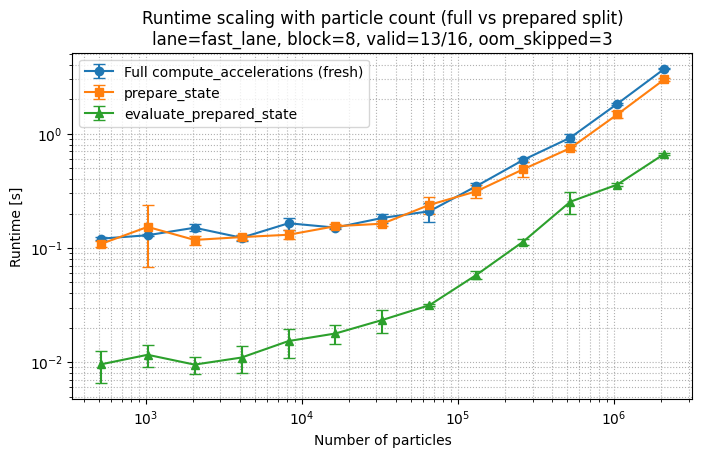

In [9]:
plot_runtime_df = runtime_df_valid if "runtime_df_valid" in globals() else runtime_df_sorted
if plot_runtime_df.empty:
    raise RuntimeError("No valid runtime rows to plot. Check runtime_df_failed for error details.")

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.errorbar(
    plot_runtime_df["num_particles"],
    plot_runtime_df["mean_seconds"],
    yerr=plot_runtime_df["std_seconds"],
    fmt="o-",
    capsize=4,
    label="Full compute_accelerations (fresh)",
)
ax.errorbar(
    plot_runtime_df["num_particles"],
    plot_runtime_df["prepare_mean_seconds"],
    yerr=plot_runtime_df["prepare_std_seconds"],
    fmt="s-",
    capsize=4,
    label="prepare_state",
)
ax.errorbar(
    plot_runtime_df["num_particles"],
    plot_runtime_df["evaluate_mean_seconds"],
    yerr=plot_runtime_df["evaluate_std_seconds"],
    fmt="^-",
    capsize=4,
    label="evaluate_prepared_state",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of particles")
ax.set_ylabel("Runtime [s]")
oom_counts = []
if "runtime_df_oom_failed" in globals() and not runtime_df_oom_failed.empty:
    oom_counts = runtime_df_oom_failed["num_particles"].astype(int).tolist()
ax.set_title(
    "Runtime scaling with particle count (full vs prepared split)\n"
    f"lane={runtime_main_sweep_lane_label}, block={runtime_main_sweep_target_block_size}, "
    f"valid={len(plot_runtime_df)}/{len(runtime_particle_counts)}, oom_skipped={len(oom_counts)}"
)
if oom_counts:
    print("OOM-skipped particle counts:", oom_counts)
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.legend()
plt.show()


OOM-skipped particle counts: [16777216]


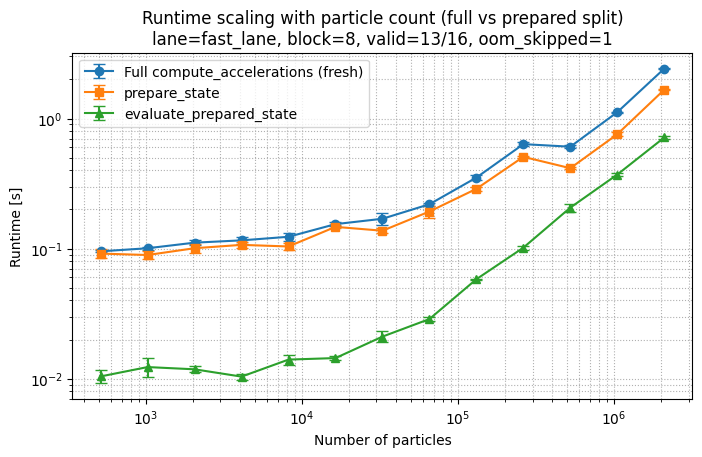

In [9]:
plot_runtime_df = runtime_df_valid if "runtime_df_valid" in globals() else runtime_df_sorted
if plot_runtime_df.empty:
    raise RuntimeError("No valid runtime rows to plot. Check runtime_df_failed for error details.")

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.errorbar(
    plot_runtime_df["num_particles"],
    plot_runtime_df["mean_seconds"],
    yerr=plot_runtime_df["std_seconds"],
    fmt="o-",
    capsize=4,
    label="Full compute_accelerations (fresh)",
)
ax.errorbar(
    plot_runtime_df["num_particles"],
    plot_runtime_df["prepare_mean_seconds"],
    yerr=plot_runtime_df["prepare_std_seconds"],
    fmt="s-",
    capsize=4,
    label="prepare_state",
)
ax.errorbar(
    plot_runtime_df["num_particles"],
    plot_runtime_df["evaluate_mean_seconds"],
    yerr=plot_runtime_df["evaluate_std_seconds"],
    fmt="^-",
    capsize=4,
    label="evaluate_prepared_state",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of particles")
ax.set_ylabel("Runtime [s]")
oom_counts = []
if "runtime_df_oom_failed" in globals() and not runtime_df_oom_failed.empty:
    oom_counts = runtime_df_oom_failed["num_particles"].astype(int).tolist()
ax.set_title(
    "Runtime scaling with particle count (full vs prepared split)\n"
    f"lane={runtime_main_sweep_lane_label}, block={runtime_main_sweep_target_block_size}, "
    f"valid={len(plot_runtime_df)}/{len(runtime_particle_counts)}, oom_skipped={len(oom_counts)}"
)
if oom_counts:
    print("OOM-skipped particle counts:", oom_counts)
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.legend()
plt.show()


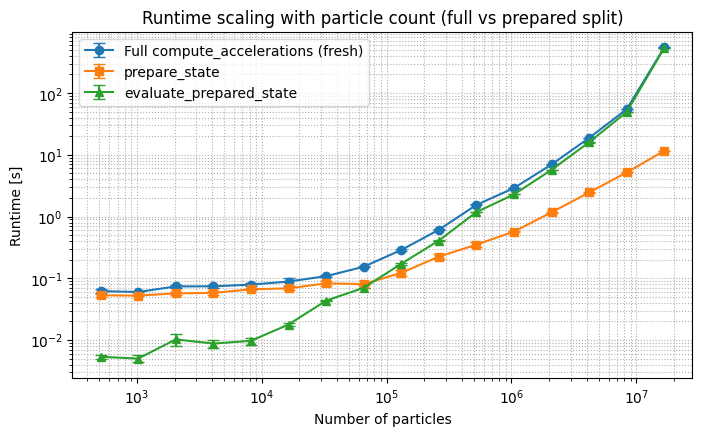

In [10]:
plot_runtime_df = runtime_df_valid if "runtime_df_valid" in globals() else runtime_df_sorted
if plot_runtime_df.empty:
    raise RuntimeError("No valid runtime rows to plot. Check runtime_df_failed for error details.")

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.errorbar(
    plot_runtime_df["num_particles"],
    plot_runtime_df["mean_seconds"],
    yerr=plot_runtime_df["std_seconds"],
    fmt="o-",
    capsize=4,
    label="Full compute_accelerations (fresh)",
)
ax.errorbar(
    plot_runtime_df["num_particles"],
    plot_runtime_df["prepare_mean_seconds"],
    yerr=plot_runtime_df["prepare_std_seconds"],
    fmt="s-",
    capsize=4,
    label="prepare_state",
)
ax.errorbar(
    plot_runtime_df["num_particles"],
    plot_runtime_df["evaluate_mean_seconds"],
    yerr=plot_runtime_df["evaluate_std_seconds"],
    fmt="^-",
    capsize=4,
    label="evaluate_prepared_state",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of particles")
ax.set_ylabel("Runtime [s]")
oom_counts = []
if "runtime_df_oom_failed" in globals() and not runtime_df_oom_failed.empty:
    oom_counts = runtime_df_oom_failed["num_particles"].astype(int).tolist()
ax.set_title(
    "Runtime scaling with particle count (full vs prepared split)\n"
    f"lane={runtime_main_sweep_lane_label}, block={runtime_main_sweep_target_block_size}, "
    f"valid={len(plot_runtime_df)}/{len(runtime_particle_counts)}, oom_skipped={len(oom_counts)}"
)
if oom_counts:
    print("OOM-skipped particle counts:", oom_counts)
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.legend()
plt.show()


## Prepared-State Steady-State and Prepare Breakdown


In [11]:
# Apples-to-apples diagnostic: yggdrax tree/traversal vs jaccpot prepare_state
import time

diag_num_particles = 131072
diag_runs = 3

diag_positions, diag_masses, _ = bench_utils.generate_random_distribution(
    diag_num_particles,
    key=jax.random.PRNGKey(123),
    dtype=runtime_working_dtype,
)

diag_fmm = FastMultipoleMethod(**runtime_fmm_kwargs)

diag_tree_type = str(getattr(diag_fmm._impl, "tree_type", "radix"))
diag_tree_mode = str(getattr(diag_fmm._impl, "tree_build_mode", "lbvh"))
diag_ygg_build_mode = "fixed_depth" if diag_tree_mode == "fixed_depth" else "adaptive"
diag_theta = float(getattr(diag_fmm._impl, "theta", runtime_fmm_kwargs.get("theta", 0.6)))
diag_traversal_cfg = diag_fmm.advanced.runtime.traversal_config
diag_mac_type = str(getattr(diag_fmm, "mac_type", "dehnen"))
diag_dehnen_radius_scale = float(getattr(diag_fmm._impl, "dehnen_radius_scale", 1.0))

print("Diagnostic setup:")
print({
    "N": diag_num_particles,
    "leaf_size": int(runtime_leaf_size),
    "tree_type": diag_tree_type,
    "tree_mode": diag_tree_mode,
    "ygg_build_mode": diag_ygg_build_mode,
    "theta": diag_theta,
    "mac_type": diag_mac_type,
})

def _block_result(x):
    if hasattr(x, "block_until_ready"):
        x.block_until_ready()
        return
    try:
        jax.tree_util.tree_map(
            lambda y: y.block_until_ready() if hasattr(y, "block_until_ready") else y,
            x,
        )
    except Exception:
        pass

def _build_tree_once():
    tree = Tree.from_particles(
        diag_positions,
        diag_masses,
        tree_type=diag_tree_type,
        build_mode=diag_ygg_build_mode,
        return_reordered=True,
        leaf_size=int(runtime_leaf_size),
    )
    if hasattr(tree, "positions_sorted"):
        jnp.asarray(tree.positions_sorted).block_until_ready()
    if hasattr(tree, "masses_sorted"):
        jnp.asarray(tree.masses_sorted).block_until_ready()
    return tree

diag_tree_for_interactions = _build_tree_once()
diag_geometry_for_interactions = compute_tree_geometry(
    diag_tree_for_interactions,
    diag_tree_for_interactions.positions_sorted,
  )
_block_result(diag_geometry_for_interactions)

def _interactions_only_once():
    interactions = build_interactions_and_neighbors(
        diag_tree_for_interactions,
        diag_geometry_for_interactions,
        theta=diag_theta,
        traversal_config=diag_traversal_cfg,
        mac_type=diag_mac_type,
        dehnen_radius_scale=diag_dehnen_radius_scale,
    )
    _block_result(interactions)
    return interactions

def _tree_plus_interactions_once():
    tree = _build_tree_once()
    geometry = compute_tree_geometry(tree, tree.positions_sorted)
    _block_result(geometry)
    interactions = build_interactions_and_neighbors(
        tree,
        geometry,
        theta=diag_theta,
        traversal_config=diag_traversal_cfg,
        mac_type=diag_mac_type,
        dehnen_radius_scale=diag_dehnen_radius_scale,
    )
    _block_result(interactions)
    return interactions

def _prepare_state_once():
    state = diag_fmm.prepare_state(
        diag_positions,
        diag_masses,
        leaf_size=int(runtime_leaf_size),
        max_order=int(runtime_max_order),
    )
    _block_result(state)
    return state

def _time_cold_steady(fn, runs=3):
    t0 = time.perf_counter()
    fn()
    cold_ms = (time.perf_counter() - t0) * 1e3

    steady_ms = []
    for _ in range(int(runs)):
        t1 = time.perf_counter()
        fn()
        steady_ms.append((time.perf_counter() - t1) * 1e3)

    arr = jnp.asarray(steady_ms, dtype=jnp.float64)
    return {
        "cold_ms": float(cold_ms),
        "steady_mean_ms": float(jnp.mean(arr)),
        "steady_min_ms": float(jnp.min(arr)),
        "steady_max_ms": float(jnp.max(arr)),
    }

diag_tree_stats = _time_cold_steady(_build_tree_once, runs=diag_runs)
diag_interactions_stats = _time_cold_steady(_interactions_only_once, runs=diag_runs)
diag_tree_interactions_stats = _time_cold_steady(_tree_plus_interactions_once, runs=diag_runs)
diag_prepare_stats = _time_cold_steady(_prepare_state_once, runs=diag_runs)

diag_compare_df = pd.DataFrame(
    [
        {"stage": "ygg_tree_only", **diag_tree_stats},
        {"stage": "ygg_interactions_only", **diag_interactions_stats},
        {"stage": "ygg_tree_plus_interactions", **diag_tree_interactions_stats},
        {"stage": "jaccpot_prepare_state", **diag_prepare_stats},
    ]
)

diag_prepare_over_tree_trav = (
    diag_prepare_stats["steady_mean_ms"]
    / max(diag_tree_interactions_stats["steady_mean_ms"], 1e-12)
)
print(
    "prepare_state / (ygg tree+interactions) steady ratio:",
    float(diag_prepare_over_tree_trav),
)

diag_compare_df

Diagnostic setup:
{'N': 131072, 'leaf_size': 256, 'tree_type': 'radix', 'tree_mode': 'lbvh', 'ygg_build_mode': 'adaptive', 'theta': 0.6, 'mac_type': 'engblom'}
[yggdrax.traversal] walk start total_nodes=1023 num_internal=511 use_count_pass=False max_interactions_per_node=None max_neighbors_per_leaf=2048 max_pair_queue=None traversal_config=DualTreeTraversalConfig(max_pair_queue=16777216, process_block=1024, max_interactions_per_node=131072, max_neighbors_per_leaf=131072) process_block=None mac_type=engblom
[yggdrax.traversal] walk start total_nodes=1023 num_internal=511 use_count_pass=False max_interactions_per_node=None max_neighbors_per_leaf=2048 max_pair_queue=None traversal_config=DualTreeTraversalConfig(max_pair_queue=16777216, process_block=1024, max_interactions_per_node=131072, max_neighbors_per_leaf=131072) process_block=None mac_type=engblom
[yggdrax.traversal] walk start total_nodes=1023 num_internal=511 use_count_pass=False max_interactions_per_node=None max_neighbors_per_l

,stage,cold_ms,steady_mean_ms,steady_min_ms,steady_max_ms
0,ygg_tree_only,6.501329,3.958406,3.115373,4.470369
1,ygg_interactions_only,9327.594305,189.106225,181.295417,203.056632
2,ygg_tree_plus_interactions,647.445669,653.876811,633.036186,680.724002
3,jaccpot_prepare_state,47811.664696,170.022643,160.257778,180.440589


In [12]:
# Why yggdrax tree_gpu_performance_scaling can look much faster:
import time
import numpy as np
from yggdrax import build_tree

cmp_n = int(diag_num_particles)
cmp_repeats = 3
cmp_leaf = int(runtime_leaf_size)

# Reuse same points/masses as the diagnostic cell if available.
cmp_positions = diag_positions if "diag_positions" in globals() else bench_utils.generate_random_distribution(cmp_n, key=jax.random.PRNGKey(321), dtype=runtime_working_dtype)[0]
cmp_masses = diag_masses if "diag_masses" in globals() else bench_utils.generate_random_distribution(cmp_n, key=jax.random.PRNGKey(322), dtype=runtime_working_dtype)[1]

def _sync_any(x):
    try:
        jax.tree_util.tree_map(
            lambda y: y.block_until_ready() if hasattr(y, "block_until_ready") else y,
            x,
        )
    except Exception:
        pass

def _time_ms(fn, *args, repeats=3, warmup=1):
    for _ in range(int(warmup)):
        _sync_any(fn(*args))
    vals = []
    for _ in range(int(repeats)):
        t0 = time.perf_counter()
        out = fn(*args)
        _sync_any(out)
        vals.append((time.perf_counter() - t0) * 1e3)
    arr = np.asarray(vals, dtype=np.float64)
    return float(np.mean(arr)), float(np.min(arr)), float(np.max(arr))

# Path A: Tree.from_particles (used in our first diagnostic cell).
def _tree_from_particles_path(p, m):
    return Tree.from_particles(
        p,
        m,
        tree_type=diag_tree_type,
        build_mode=diag_ygg_build_mode,  # maps lbvh -> adaptive in this wrapper path
        return_reordered=True,
        leaf_size=cmp_leaf,
    )

# Path B: build_tree + JIT (used in yggdrax tree_gpu_performance_scaling notebook).
build_tree_jit = jax.jit(
    lambda p, m: build_tree(
        p,
        m,
        leaf_size=cmp_leaf,
        return_reordered=True,
    )
)

mean_a, min_a, max_a = _time_ms(_tree_from_particles_path, cmp_positions, cmp_masses, repeats=cmp_repeats, warmup=1)
mean_b, min_b, max_b = _time_ms(build_tree_jit, cmp_positions, cmp_masses, repeats=cmp_repeats, warmup=1)

api_compare_df = pd.DataFrame([
    {
        "path": "Tree.from_particles (wrapper)",
        "mean_ms": mean_a,
        "min_ms": min_a,
        "max_ms": max_a,
    },
    {
        "path": "jax.jit(build_tree)",
        "mean_ms": mean_b,
        "min_ms": min_b,
        "max_ms": max_b,
    },
])
api_compare_df["speedup_vs_wrapper"] = api_compare_df["mean_ms"].iloc[0] / api_compare_df["mean_ms"]
print("N:", cmp_n, "leaf:", cmp_leaf)
api_compare_df

N: 131072 leaf: 256


,path,mean_ms,min_ms,max_ms,speedup_vs_wrapper
0,Tree.from_particles (wrapper),3.478133,3.150561,3.941447,1.000000
1,jax.jit(build_tree),5.040871,2.205223,9.176560,0.689987


In [13]:
# Fair yggdrax-style radix traversal timing (jitted build_tree + jitted geometry + return_result=False)
from yggdrax import DualTreeTraversalConfig

trav_cap = (262144, 8192, 4096)
trav_cfg = DualTreeTraversalConfig(
    max_pair_queue=int(trav_cap[0]),
    process_block=256,
    max_interactions_per_node=int(trav_cap[1]),
    max_neighbors_per_leaf=int(trav_cap[2]),
)

tree_build_fn = jax.jit(
    lambda p, m: build_tree(
        p,
        m,
        leaf_size=int(runtime_leaf_size),
        return_reordered=True,
    )
)
geom_fn = jax.jit(lambda t, p: compute_tree_geometry(t, p))
trav_fn = jax.jit(
    lambda t, g: build_interactions_and_neighbors(
        t,
        g,
        theta=float(diag_theta),
        mac_type=str(diag_mac_type),
        traversal_config=trav_cfg,
        return_result=False,
    )
)

# Build + geometry once for traversal-only timing.
tree_payload = tree_build_fn(diag_positions, diag_masses)
_sync_any(tree_payload)
tree_obj, pos_sorted, _masses_sorted, _inv = tree_payload
geom_obj = geom_fn(tree_obj, pos_sorted)
_sync_any(geom_obj)

def _trav_only():
    return trav_fn(tree_obj, geom_obj)

trav_mean, trav_min, trav_max = _time_ms(_trav_only, repeats=3, warmup=1)
fair_trav_df = pd.DataFrame([
    {
        "benchmark_style": "yggdrax notebook style",
        "n": int(diag_num_particles),
        "leaf_size": int(runtime_leaf_size),
        "traversal_mean_ms": float(trav_mean),
        "traversal_min_ms": float(trav_min),
        "traversal_max_ms": float(trav_max),
    }
])
fair_trav_df

[yggdrax.traversal] walk start total_nodes=1023 num_internal=511 use_count_pass=False max_interactions_per_node=None max_neighbors_per_leaf=2048 max_pair_queue=None traversal_config=DualTreeTraversalConfig(max_pair_queue=262144, process_block=256, max_interactions_per_node=8192, max_neighbors_per_leaf=4096) process_block=None mac_type=engblom


,benchmark_style,n,leaf_size,traversal_mean_ms,traversal_min_ms,traversal_max_ms
0,yggdrax notebook style,131072,256,18.058671,11.650364,25.590984


In [14]:
# MAC runtime comparison on the same diagnostic radix setup
from yggdrax import build_tree, compute_tree_geometry
from yggdrax.interactions import DualTreeTraversalConfig, build_interactions_and_neighbors
import numpy as np 
mac_trav_cfg = getattr(
    getattr(getattr(diag_fmm, "advanced", None), "runtime", None),
    "traversal_config",
    None,
)
if mac_trav_cfg is None:
    mac_trav_cfg = DualTreeTraversalConfig(
        max_pair_queue=262144,
        process_block=256,
        max_interactions_per_node=8192,
        max_neighbors_per_leaf=4096,
    )

mac_compare_specs = [
    dict(label="bh", mac_type="bh"),
    dict(label="dehnen", mac_type="dehnen"),
    dict(label="engblom", mac_type="engblom"),
    dict(label="dehnen_error", mac_type="dehnen_error"),
]

def _mac_sync_any(x):
    try:
        jax.tree_util.tree_map(
            lambda y: y.block_until_ready() if hasattr(y, "block_until_ready") else y,
            x,
        )
    except Exception:
        pass


def _mac_time_ms(fn, repeats=3, warmup=1):
    for _ in range(int(warmup)):
        _mac_sync_any(fn())
    vals = []
    for _ in range(int(repeats)):
        t0 = time.perf_counter()
        out = fn()
        _mac_sync_any(out)
        vals.append((time.perf_counter() - t0) * 1e3)
    arr = np.asarray(vals, dtype=np.float64)
    return float(np.mean(arr)), float(np.min(arr)), float(np.max(arr))

mac_tree_build_fn = jax.jit(
    lambda p, m: build_tree(
        p,
        m,
        leaf_size=int(runtime_leaf_size),
        return_reordered=True,
    )
)
mac_geom_fn = jax.jit(lambda t, p: compute_tree_geometry(t, p))

mac_tree_payload = mac_tree_build_fn(diag_positions, diag_masses)
_mac_sync_any(mac_tree_payload)
mac_tree_obj, mac_pos_sorted, _mac_masses_sorted, _mac_inv = mac_tree_payload
mac_geom_obj = mac_geom_fn(mac_tree_obj, mac_pos_sorted)
_mac_sync_any(mac_geom_obj)

mac_compare_rows = []
for spec in mac_compare_specs:
    mac_type = str(spec["mac_type"])
    traversal_mac_type = "dehnen" if mac_type == "dehnen_error" else mac_type

    scenario_fmm_kwargs = dict(runtime_fmm_kwargs)
    scenario_fmm_kwargs["advanced"] = replace(runtime_advanced, mac_type=mac_type)
    mac_fmm = FastMultipoleMethod(**scenario_fmm_kwargs)

    def _prepare_mac_once():
        state = mac_fmm.prepare_state(
            diag_positions,
            diag_masses,
            leaf_size=int(runtime_leaf_size),
            max_order=int(runtime_max_order),
        )
        _block_result(state)
        return state

    trav_fn_mac = jax.jit(
        lambda t, g, traversal_mac_type=traversal_mac_type: build_interactions_and_neighbors(
            t,
            g,
            theta=float(diag_theta),
            mac_type=str(traversal_mac_type),
            traversal_config=mac_trav_cfg,
            dehnen_radius_scale=float(diag_dehnen_radius_scale),
            return_result=False,
        )
    )

    def _trav_only_mac():
        return trav_fn_mac(mac_tree_obj, mac_geom_obj)

    prepare_stats = _time_cold_steady(_prepare_mac_once, runs=diag_runs)
    trav_mean, trav_min, trav_max = _mac_time_ms(_trav_only_mac, repeats=diag_runs, warmup=1)

    mac_compare_rows.append(
        {
            "mac_type": mac_type,
            "traversal_mac_type": traversal_mac_type,
            "prepare_cold_ms": prepare_stats["cold_ms"],
            "prepare_steady_mean_ms": prepare_stats["steady_mean_ms"],
            "prepare_steady_min_ms": prepare_stats["steady_min_ms"],
            "prepare_steady_max_ms": prepare_stats["steady_max_ms"],
            "yggdrax_traversal_mean_ms": trav_mean,
            "yggdrax_traversal_min_ms": trav_min,
            "yggdrax_traversal_max_ms": trav_max,
        }
    )

mac_compare_df = (
    pd.DataFrame(mac_compare_rows)
    .sort_values("prepare_steady_mean_ms")
    .reset_index(drop=True)
)
mac_compare_df


[jaccpot.prepare] tree built particles=131072 leaf_size=256 total_nodes=1023 num_internal=511 num_leaves=512 tree_type=radix tree_mode=lbvh jit_tree=True
[jaccpot.prepare] upward start max_order=4 center_mode=com leaf_cap=256 upward_leaf_batch_size=2048
[jaccpot.upward] geometry start particles=131072 max_order=4 rotation=solidfmm
[jaccpot.upward] geometry done
[jaccpot.upward] mass moments done
[jaccpot.upward] batch sizing total_nodes=1023 num_internal=511 num_leaves=512 resolved_leaf_batch_size=2048 num_levels=64 level_batch_width=511
[jaccpot.upward] stage estimates mass_prefix=512.00KiB weighted_prefix=1.50MiB total_mass=4.00KiB centers=11.99KiB p2m_leaf_points=1.50MiB p2m_leaf_masses=512.00KiB p2m_leaf_contribs=25.00MiB packed=199.80KiB
[jaccpot.upward] p2m start
[jaccpot.upward] p2m done packed_shape=(1023, 25)
[jaccpot.upward] m2m start
[jaccpot.upward] m2m done
[jaccpot.prepare] upward done multipole_order=4 multipole_shape=(1023, 25)
[jaccpot.prepare] dual-tree start theta=0.

,mac_type,traversal_mac_type,prepare_cold_ms,prepare_steady_mean_ms,prepare_steady_min_ms,prepare_steady_max_ms,yggdrax_traversal_mean_ms,yggdrax_traversal_min_ms,yggdrax_traversal_max_ms
0,bh,bh,17229.357996,129.575458,122.606683,136.911273,150.411278,146.000755,158.981275
1,engblom,engblom,703.096511,171.718958,151.254324,196.828173,159.748387,149.995558,167.985557
2,dehnen,dehnen,20302.903948,201.785324,184.870551,216.817682,117.181530,105.875202,128.698217
3,dehnen_error,dehnen,48888.670502,20307.192062,20248.689697,20337.990438,109.348119,106.064402,113.177541


In [15]:
mac_runtime_sweep_specs = [
    dict(label="bh", mac_type="bh"),
    dict(label="dehnen", mac_type="dehnen"),
    dict(label="engblom", mac_type="engblom"),
    dict(label="dehnen_error", mac_type="dehnen_error"),
]

mac_runtime_sweep_frames = []
for spec in mac_runtime_sweep_specs:
    scenario_kwargs = override_fmm_kwargs(
        runtime_fmm_kwargs,
        mac_type=str(spec["mac_type"]),
    )
    scenario_df = sweep_runtimes(
        runtime_particle_counts,
        leaf_size=runtime_leaf_size,
        max_order=runtime_max_order,
        runs=runtime_runs,
        warmup=runtime_warmup,
        dtype=runtime_working_dtype,
        key=runtime_key,
        fmm_kwargs=scenario_kwargs,
    ).copy()
    scenario_df["mac_type"] = str(spec["mac_type"])
    scenario_df["label"] = str(spec["label"])
    mac_runtime_sweep_frames.append(scenario_df)

mac_runtime_sweep_df = (
    pd.concat(mac_runtime_sweep_frames, ignore_index=True)
    .sort_values(["mac_type", "num_particles"])
    .reset_index(drop=True)
)
mac_runtime_sweep_df


KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)

plot_specs = [
    ("mean_seconds", "std_seconds", "Full compute_accelerations", "o"),
    ("prepare_mean_seconds", "prepare_std_seconds", "prepare_state", "s"),
    ("evaluate_mean_seconds", "evaluate_std_seconds", "evaluate_prepared_state", "^")
]

for ax, (mean_col, std_col, title, marker) in zip(axes, plot_specs):
    for mac_type, group in mac_runtime_sweep_df.groupby("mac_type"):
        g = group.sort_values("num_particles")
        ax.errorbar(
            g["num_particles"],
            g[mean_col],
            yerr=g[std_col],
            fmt=f"{marker}-",
            capsize=4,
            label=mac_type,
        )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Number of particles")
    ax.set_ylabel("Runtime [s]")
    ax.set_title(title)
    ax.grid(True, which="both", linestyle=":", linewidth=0.8)

axes[0].legend(title="MAC")
fig.suptitle("Runtime scaling by MAC criterion", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
runtime_prepared_df = sweep_prepared_eval_runtimes(
    runtime_particle_counts,
    leaf_size=runtime_leaf_size,
    max_order=runtime_max_order,
    runs=runtime_runs,
    warmup=runtime_warmup,
    dtype=runtime_working_dtype,
    key=runtime_key,
    fmm_kwargs=runtime_fmm_kwargs,
)
runtime_prepared_df


In [ ]:
runtime_steady_df = runtime_df.merge(runtime_prepared_df, on="num_particles", suffixes=("", "_prepared"))
runtime_steady_sorted = runtime_steady_df.sort_values("num_particles")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(
    runtime_steady_sorted["num_particles"],
    runtime_steady_sorted["mean_seconds"],
    yerr=runtime_steady_sorted["std_seconds"],
    fmt="o-",
    capsize=4,
    label="Full compute_accelerations (fresh)",
)
ax.errorbar(
    runtime_steady_sorted["num_particles"],
    runtime_steady_sorted["prepared_eval_mean_seconds"],
    yerr=runtime_steady_sorted["prepared_eval_std_seconds"],
    fmt="s-",
    capsize=4,
    label="evaluate_prepared_state steady-state",
)
ax.errorbar(
    runtime_steady_sorted["num_particles"],
    runtime_steady_sorted["prepared_eval_jit_mean_seconds"],
    yerr=runtime_steady_sorted["prepared_eval_jit_std_seconds"],
    fmt="^-",
    capsize=4,
    label="jax.jit(evaluate_prepared_state)",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of particles")
ax.set_ylabel("Runtime [s]")
ax.set_title("Steady-state runtime scaling")
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.legend()
plt.show()


In [ ]:
runtime_component_df = profile_prepare_components_runtime(
    runtime_particle_counts,
    leaf_size=runtime_leaf_size,
    max_order=runtime_max_order,
    dtype=runtime_working_dtype,
    key=runtime_key,
    fmm_kwargs=runtime_fmm_kwargs,
    runs=max(1, runtime_runs),
    warmup=runtime_warmup,
)
runtime_component_df


In [ ]:
runtime_component_sorted = runtime_component_df.sort_values("num_particles")

fig, ax = plt.subplots(figsize=(8, 4.5))
for col, label, marker in [
    ("tree_build_mean_seconds", "tree build", "o"),
    ("upward_mean_seconds", "upward", "s"),
    ("interactions_mean_seconds", "interactions", "^"),
    ("downward_mean_seconds", "downward", "d"),
    ("prepare_component_sum_seconds", "component sum", "x"),
]:
    ax.plot(
        runtime_component_sorted["num_particles"],
        runtime_component_sorted[col],
        marker=marker,
        label=label,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of particles")
ax.set_ylabel("Runtime [s]")
ax.set_title("prepare_state component breakdown")
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.legend()
plt.show()


### Near-Field Scatter Schedule A/B (Prepared Eval)\n
Compare `evaluate_prepared_state` with precomputed near-field chunk schedules enabled vs disabled.\n

In [ ]:
schedule_ab_num_particles = int(min(16384, max(runtime_particle_counts)))

schedule_ab_runs = max(2, runtime_runs)

schedule_ab_warmup = runtime_warmup



schedule_ab_kwargs = override_fmm_kwargs(
    runtime_fmm_kwargs,
    grouped_interactions=True,
    farfield_mode="class_major",
    nearfield_mode="bucketed",
    nearfield_edge_chunk_size=256,
)



schedule_ab_fmm = FastMultipoleMethod(**schedule_ab_kwargs)

schedule_ab_pos, schedule_ab_mass, _ = bench_utils.generate_random_distribution(

    schedule_ab_num_particles,

    key=runtime_key,

    dtype=runtime_working_dtype,

)



schedule_ab_state = schedule_ab_fmm.prepare_state(

    schedule_ab_pos,

    schedule_ab_mass,

    leaf_size=runtime_leaf_size,

    max_order=runtime_max_order,

)



schedule_ab_state_no_sched = schedule_ab_state._replace(

    nearfield_chunk_sort_indices=None,

    nearfield_chunk_group_ids=None,

    nearfield_chunk_unique_indices=None,

)



schedule_eval_with = bench_utils.time_callable(

    schedule_ab_fmm.evaluate_prepared_state,

    schedule_ab_state,


    warmup=schedule_ab_warmup,

    runs=schedule_ab_runs,

)

schedule_eval_without = bench_utils.time_callable(

    schedule_ab_fmm.evaluate_prepared_state,

    schedule_ab_state_no_sched,


    warmup=schedule_ab_warmup,

    runs=schedule_ab_runs,

)



schedule_ab_df = pd.DataFrame([

    {

        "num_particles": schedule_ab_num_particles,

        "evaluate_mean_with_schedule_s": schedule_eval_with.mean,

        "evaluate_std_with_schedule_s": schedule_eval_with.std,

        "evaluate_mean_without_schedule_s": schedule_eval_without.mean,

        "evaluate_std_without_schedule_s": schedule_eval_without.std,

        "speedup_without_over_with": schedule_eval_without.mean / schedule_eval_with.mean,

    }

])

schedule_ab_df


In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))
labels = ["with schedule", "without schedule"]
means = [
    float(schedule_ab_df["evaluate_mean_with_schedule_s"].iloc[0]),
    float(schedule_ab_df["evaluate_mean_without_schedule_s"].iloc[0]),
]
stds = [
    float(schedule_ab_df["evaluate_std_with_schedule_s"].iloc[0]),
    float(schedule_ab_df["evaluate_std_without_schedule_s"].iloc[0]),
]
ax.bar(labels, means, yerr=stds, capsize=5, color=["#2a9d8f", "#e76f51"])
ax.set_ylabel("evaluate_prepared_state runtime [s]")
ax.set_title(f"Near-field schedule A/B @ N={schedule_ab_num_particles}")
ax.grid(True, axis="y", linestyle=":", linewidth=0.8)
plt.show()
print("Speedup (without/with):", float(schedule_ab_df["speedup_without_over_with"].iloc[0]))

## Sparse vs Grouped Runtime Scaling

Compare end-to-end runtime for the same solidfmm+dehnen setup with
`grouped_interactions=False` (sparse baseline) and `grouped_interactions=True` (grouped path).


In [ ]:
runtime_compare_particle_counts = [1024, 4096, 16384, 65536]#, 262144, 524288, 1048576, 2097152]#, 4194304]
runtime_compare_runs = 2
runtime_compare_warmup = 1

runtime_sparse_kwargs = override_fmm_kwargs(runtime_fmm_kwargs, grouped_interactions=False)

runtime_grouped_kwargs = override_fmm_kwargs(runtime_fmm_kwargs, grouped_interactions=True)

runtime_sparse_df = sweep_runtimes(
    runtime_compare_particle_counts,
    leaf_size=runtime_leaf_size,
    max_order=runtime_max_order,
    runs=runtime_compare_runs,
    warmup=runtime_compare_warmup,
    dtype=runtime_working_dtype,
    key=runtime_key,
    fmm_kwargs=runtime_sparse_kwargs,
)

runtime_grouped_df = sweep_runtimes(
    runtime_compare_particle_counts,
    leaf_size=runtime_leaf_size,
    max_order=runtime_max_order,
    runs=runtime_compare_runs,
    warmup=runtime_compare_warmup,
    dtype=runtime_working_dtype,
    key=runtime_key,
    fmm_kwargs=runtime_grouped_kwargs,
)

runtime_compare_df = runtime_sparse_df.merge(
    runtime_grouped_df,
    on="num_particles",
    suffixes=("_sparse", "_grouped"),
)
runtime_compare_df["speedup_full"] = (
    runtime_compare_df["mean_seconds_sparse"]
    / runtime_compare_df["mean_seconds_grouped"]
)
runtime_compare_df


In [ ]:
runtime_compare_sorted = runtime_compare_df.sort_values("num_particles")

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.errorbar(
    runtime_compare_sorted["num_particles"],
    runtime_compare_sorted["mean_seconds_sparse"],
    yerr=runtime_compare_sorted["std_seconds_sparse"],
    fmt="o--",
    capsize=4,
    label="Sparse (grouped_interactions=False)",
)
ax.errorbar(
    runtime_compare_sorted["num_particles"],
    runtime_compare_sorted["mean_seconds_grouped"],
    yerr=runtime_compare_sorted["std_seconds_grouped"],
    fmt="s-",
    capsize=4,
    label="Grouped (grouped_interactions=True)",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of particles")
ax.set_ylabel("Runtime [s]")
ax.set_title("Full compute_accelerations: sparse vs grouped scaling")
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.legend()
plt.show()

print(
    "Geometric-mean full-runtime speedup (sparse/grouped):",
    float(
        jnp.exp(jnp.mean(jnp.log(runtime_compare_sorted["speedup_full"].to_numpy())))
    ),
)

In [ ]:
runtime_compare_sorted = runtime_compare_df.sort_values("num_particles")

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.errorbar(
    runtime_compare_sorted["num_particles"],
    runtime_compare_sorted["mean_seconds_sparse"],
    yerr=runtime_compare_sorted["std_seconds_sparse"],
    fmt="o--",
    capsize=4,
    label="Sparse (grouped_interactions=False)",
)
ax.errorbar(
    runtime_compare_sorted["num_particles"],
    runtime_compare_sorted["mean_seconds_grouped"],
    yerr=runtime_compare_sorted["std_seconds_grouped"],
    fmt="s-",
    capsize=4,
    label="Grouped (grouped_interactions=True)",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of particles")
ax.set_ylabel("Runtime [s]")
ax.set_title("Full compute_accelerations: sparse vs grouped scaling")
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.legend()
plt.show()

print(
    "Geometric-mean full-runtime speedup (sparse/grouped):",
    float(jnp.exp(jnp.mean(jnp.log(runtime_compare_sorted["speedup_full"].to_numpy())))),
)


## Pair-Grouped vs Class-Major Far-Field Scaling

Both runs below use `grouped_interactions=True` and only differ in
`farfield_mode` (`"pair_grouped"` vs `"class_major"`).
For now the `"class_major"` option is very slow and has some overhead. so we either need to further develop this or kill this option.


In [ ]:
runtime_default_particle_counts = [
    1024,
    4096,
    #16384,
    #65536
]  # [262144]#, 524288, 1048576, 2097152]
runtime_farfield_particle_counts = globals().get("runtime_farfield_particle_counts", runtime_default_particle_counts)
runtime_farfield_runs = globals().get("runtime_compare_runs", 2)
runtime_farfield_warmup = globals().get("runtime_compare_warmup", 1)


runtime_pair_grouped_kwargs = override_fmm_kwargs(
    runtime_fmm_kwargs, grouped_interactions=True, farfield_mode="pair_grouped"
)

runtime_class_major_kwargs = override_fmm_kwargs(
    runtime_fmm_kwargs, grouped_interactions=True, farfield_mode="class_major"
)

runtime_pair_grouped_df = sweep_runtimes(
    runtime_farfield_particle_counts,
    leaf_size=runtime_leaf_size,
    max_order=runtime_max_order,
    runs=runtime_farfield_runs,
    warmup=runtime_farfield_warmup,
    dtype=runtime_working_dtype,
    key=runtime_key,
    fmm_kwargs=runtime_pair_grouped_kwargs,
)

runtime_class_major_df = sweep_runtimes(
    runtime_farfield_particle_counts,
    leaf_size=runtime_leaf_size,
    max_order=runtime_max_order,
    runs=runtime_farfield_runs,
    warmup=runtime_farfield_warmup,
    dtype=runtime_working_dtype,
    key=runtime_key,
    fmm_kwargs=runtime_class_major_kwargs,
)

runtime_farfield_compare_df = runtime_pair_grouped_df.merge(
    runtime_class_major_df,
    on="num_particles",
    suffixes=("_pair_grouped", "_class_major"),
)
runtime_farfield_compare_df["speedup_full"] = (
    runtime_farfield_compare_df["mean_seconds_pair_grouped"]
    / runtime_farfield_compare_df["mean_seconds_class_major"]
)
runtime_farfield_compare_df

In [ ]:
runtime_farfield_sorted = runtime_farfield_compare_df.sort_values("num_particles")

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.errorbar(
    runtime_farfield_sorted["num_particles"],
    runtime_farfield_sorted["mean_seconds_pair_grouped"],
    yerr=runtime_farfield_sorted["std_seconds_pair_grouped"],
    fmt="o--",
    capsize=4,
    label="pair_grouped",
)
ax.errorbar(
    runtime_farfield_sorted["num_particles"],
    runtime_farfield_sorted["mean_seconds_class_major"],
    yerr=runtime_farfield_sorted["std_seconds_class_major"],
    fmt="s-",
    capsize=4,
    label="class_major",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of particles")
ax.set_ylabel("Runtime [s]")
ax.set_title("Grouped far-field modes: pair_grouped vs class_major")
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.legend()
plt.show()

print(
    "Geometric-mean full-runtime speedup (pair_grouped/class_major):",
    float(
        jnp.exp(
            jnp.mean(jnp.log(runtime_farfield_sorted["speedup_full"].to_numpy()))
        )
    ),
)


## Near-Field Mode Scaling

Compare near-field execution modes while keeping far-field settings fixed
(`grouped_interactions=True`, `farfield_mode="class_major"`).


In [ ]:
runtime_default_particle_counts = [262144, 524288]#, 1048576, 2097152]
runtime_nearfield_particle_counts = globals().get("runtime_nearfield_particle_counts", runtime_default_particle_counts)
runtime_nearfield_runs = globals().get("runtime_compare_runs", 2)
runtime_nearfield_warmup = globals().get("runtime_compare_warmup", 1)


runtime_nearfield_baseline_kwargs = override_fmm_kwargs(
    runtime_fmm_kwargs,
    grouped_interactions=True,
    farfield_mode="class_major",
    nearfield_mode="baseline",
)

runtime_nearfield_bucketed_kwargs = override_fmm_kwargs(
    runtime_fmm_kwargs,
    grouped_interactions=True,
    farfield_mode="class_major",
    nearfield_mode="bucketed",
    nearfield_edge_chunk_size=256,
)

runtime_nearfield_baseline_df = sweep_runtimes(
    runtime_nearfield_particle_counts,
    leaf_size=runtime_leaf_size,
    max_order=runtime_max_order,
    runs=runtime_nearfield_runs,
    warmup=runtime_nearfield_warmup,
    dtype=runtime_working_dtype,
    key=runtime_key,
    fmm_kwargs=runtime_nearfield_baseline_kwargs,
)

runtime_nearfield_bucketed_df = sweep_runtimes(
    runtime_nearfield_particle_counts,
    leaf_size=runtime_leaf_size,
    max_order=runtime_max_order,
    runs=runtime_nearfield_runs,
    warmup=runtime_nearfield_warmup,
    dtype=runtime_working_dtype,
    key=runtime_key,
    fmm_kwargs=runtime_nearfield_bucketed_kwargs,
)

runtime_nearfield_compare_df = runtime_nearfield_baseline_df.merge(
    runtime_nearfield_bucketed_df,
    on="num_particles",
    suffixes=("_baseline", "_bucketed"),
)
runtime_nearfield_compare_df["speedup_full"] = (
    runtime_nearfield_compare_df["mean_seconds_baseline"]
    / runtime_nearfield_compare_df["mean_seconds_bucketed"]
)
runtime_nearfield_compare_df


In [ ]:
runtime_nearfield_sorted = runtime_nearfield_compare_df.sort_values("num_particles")

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.errorbar(
    runtime_nearfield_sorted["num_particles"],
    runtime_nearfield_sorted["mean_seconds_baseline"],
    yerr=runtime_nearfield_sorted["std_seconds_baseline"],
    fmt="o--",
    capsize=4,
    label="nearfield baseline",
)
ax.errorbar(
    runtime_nearfield_sorted["num_particles"],
    runtime_nearfield_sorted["mean_seconds_bucketed"],
    yerr=runtime_nearfield_sorted["std_seconds_bucketed"],
    fmt="s-",
    capsize=4,
    label="nearfield bucketed",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of particles")
ax.set_ylabel("Runtime [s]")
ax.set_title("Near-field mode scaling (full compute_accelerations)")
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.legend()
plt.show()

print(
    "Geometric-mean full-runtime speedup (nearfield baseline/bucketed):",
    float(
        jnp.exp(
            jnp.mean(jnp.log(runtime_nearfield_sorted["speedup_full"].to_numpy()))
        )
    ),
)


### Near-Field Split Diagnostics (prepare vs evaluate)

Use the same near-field sweep results to inspect whether gains come from
`prepare_state` or `evaluate_prepared_state`.


In [ ]:
runtime_nearfield_split_df = runtime_nearfield_compare_df.copy()
runtime_nearfield_split_df["speedup_prepare"] = (
    runtime_nearfield_split_df["prepare_mean_seconds_baseline"]
    / runtime_nearfield_split_df["prepare_mean_seconds_bucketed"]
)
runtime_nearfield_split_df["speedup_evaluate"] = (
    runtime_nearfield_split_df["evaluate_mean_seconds_baseline"]
    / runtime_nearfield_split_df["evaluate_mean_seconds_bucketed"]
)
runtime_nearfield_split_df[
    [
        "num_particles",
        "prepare_mean_seconds_baseline",
        "prepare_mean_seconds_bucketed",
        "speedup_prepare",
        "evaluate_mean_seconds_baseline",
        "evaluate_mean_seconds_bucketed",
        "speedup_evaluate",
    ]
]


In [ ]:
runtime_nearfield_split_sorted = runtime_nearfield_split_df.sort_values("num_particles")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

axes[0].errorbar(
    runtime_nearfield_split_sorted["num_particles"],
    runtime_nearfield_split_sorted["prepare_mean_seconds_baseline"],
    yerr=runtime_nearfield_split_sorted["prepare_std_seconds_baseline"],
    fmt="o--",
    capsize=4,
    label="prepare baseline",
)
axes[0].errorbar(
    runtime_nearfield_split_sorted["num_particles"],
    runtime_nearfield_split_sorted["prepare_mean_seconds_bucketed"],
    yerr=runtime_nearfield_split_sorted["prepare_std_seconds_bucketed"],
    fmt="s-",
    capsize=4,
    label="prepare bucketed",
)

axes[1].errorbar(
    runtime_nearfield_split_sorted["num_particles"],
    runtime_nearfield_split_sorted["evaluate_mean_seconds_baseline"],
    yerr=runtime_nearfield_split_sorted["evaluate_std_seconds_baseline"],
    fmt="o--",
    capsize=4,
    label="evaluate baseline",
)
axes[1].errorbar(
    runtime_nearfield_split_sorted["num_particles"],
    runtime_nearfield_split_sorted["evaluate_mean_seconds_bucketed"],
    yerr=runtime_nearfield_split_sorted["evaluate_std_seconds_bucketed"],
    fmt="s-",
    capsize=4,
    label="evaluate bucketed",
)

for ax, title in zip(axes, ["prepare_state", "evaluate_prepared_state"]):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Number of particles")
    ax.set_ylabel("Runtime [s]")
    ax.set_title(title)
    ax.grid(True, which="both", linestyle=":", linewidth=0.8)
    ax.legend()

plt.tight_layout()
plt.show()

print(
    "Geometric-mean speedup prepare (baseline/bucketed):",
    float(jnp.exp(jnp.mean(jnp.log(runtime_nearfield_split_sorted["speedup_prepare"].to_numpy())))),
)
print(
    "Geometric-mean speedup evaluate (baseline/bucketed):",
    float(jnp.exp(jnp.mean(jnp.log(runtime_nearfield_split_sorted["speedup_evaluate"].to_numpy())))),
)


## Prepare-state micro-profile (publication-focused)

This section profiles `prepare_state` internals to explain residual runtime after tree-build parity fixes.

What it measures per call:
- total `prepare_state` wall time
- tree + upward stage
- dual-tree + downward stage
- key nested kernels (`prepare_upward_sweep`, dual-tree builder, downward builder)

Use this for reproducible figures/tables in future writeups.

In [ ]:
import time
from collections import defaultdict
from contextlib import ExitStack, contextmanager

import jaccpot.runtime._fmm_impl as _jfmm_impl


def _block_tree(x):
    try:
        jax.tree_util.tree_map(
            lambda y: y.block_until_ready() if hasattr(y, "block_until_ready") else y,
            x,
        )
    except Exception:
        pass


@contextmanager
def _timed_method(obj, attr_name, sink, *, label=None, sync_output=True):
    """Monkeypatch one callable and record wall time in milliseconds."""
    original = getattr(obj, attr_name)
    key = attr_name if label is None else str(label)

    def wrapped(*args, **kwargs):
        t0 = time.perf_counter()
        out = original(*args, **kwargs)
        if sync_output:
            _block_tree(out)
        sink[key].append((time.perf_counter() - t0) * 1e3)
        return out

    setattr(obj, attr_name, wrapped)
    try:
        yield
    finally:
        setattr(obj, attr_name, original)


def profile_prepare_substages(
    num_particles,
    *,
    fmm_kwargs,
    leaf_size,
    max_order,
    dtype,
    key,
    warmup=1,
    runs=3,
 ):
    """Profile prepare_state internals for one particle count."""
    fmm = FastMultipoleMethod(**fmm_kwargs)
    positions, masses, _ = bench_utils.generate_random_distribution(
        int(num_particles), key=key, dtype=dtype
    )

    stats = defaultdict(list)
    wrappers = [
        (fmm._impl, "_prepare_state_tree_and_upward", "tree_upward_total"),
        (fmm._impl, "prepare_upward_sweep", "upward_sweep"),
        (fmm._impl, "_prepare_state_dual_and_downward", "dual_downward_total"),
        (fmm._impl, "_prepare_downward_with_artifacts", "downward_build"),
        (fmm._impl, "_prepare_state_nearfield_artifacts", "nearfield_artifacts"),
        (_jfmm_impl, "_build_tree_with_config", "tree_build_lowlevel"),
        (_jfmm_impl, "_build_dual_tree_artifacts", "dual_tree_build"),
        (_jfmm_impl, "_build_nearfield_interop_data", "nearfield_interop"),
    ]

    with ExitStack() as stack:
        for obj, attr, label in wrappers:
            stack.enter_context(
                _timed_method(obj, attr, stats, label=label, sync_output=True)
            )

        total_ms = []
        for i in range(int(warmup) + int(runs)):
            t0 = time.perf_counter()
            state = fmm.prepare_state(
                positions,
                masses,
                leaf_size=int(leaf_size),
                max_order=int(max_order),
            )
            _block_tree(state)
            dt = (time.perf_counter() - t0) * 1e3
            total_ms.append(dt)

    keep_slice = slice(int(warmup), None)
    total_keep = total_ms[keep_slice] if len(total_ms) > int(warmup) else total_ms
    row = {
        "num_particles": int(num_particles),
        "prepare_total_ms": float(jnp.mean(jnp.asarray(total_keep))),
    }

    for label, vals in stats.items():
        vals_keep = vals[keep_slice] if len(vals) > int(warmup) else vals
        row[f"{label}_ms"] = float(jnp.mean(jnp.asarray(vals_keep)))

    row["residual_ms"] = max(
        row["prepare_total_ms"]
        - row.get("tree_upward_total_ms", 0.0)
        - row.get("dual_downward_total_ms", 0.0),
        0.0,
    )
    return row

In [ ]:
# Sweep selected N values and collect publication-friendly profiling tables.
# Bootstrap defaults so this section can run independently of earlier config cells.
if "runtime_fmm_kwargs" not in globals():
    runtime_leaf_size = int(globals().get("runtime_leaf_size", 256))
    runtime_max_order = int(globals().get("runtime_max_order", 4))
    runtime_working_dtype = globals().get("runtime_working_dtype", jnp.float32)
    softening = float(globals().get("softening", 1e-3))

    from jaccpot import (
        FMMAdvancedConfig,
        FMMPreset,
        FarFieldConfig,
        FastMultipoleMethod,
        NearFieldConfig,
        RuntimePolicyConfig,
        TreeConfig,
    )
    from yggdrax.interactions import DualTreeTraversalConfig

    runtime_mac_type = "engblom"
    runtime_memory_first_m2l_chunk_size = 1024
    runtime_baseline_num_particles = int(globals().get("runtime_baseline_num_particles", 1048576))
    runtime_baseline_traversal = runtime_traversal_seed_for_num_particles(runtime_baseline_num_particles)
    BEST_TRAVERSAL_CONFIG = None
    runtime_advanced = FMMAdvancedConfig(
        tree=TreeConfig(
            tree_type="radix",
            mode="lbvh",
            leaf_target=runtime_leaf_size,
            refine_local=False,
            max_refine_levels=0,
            aspect_threshold=16.0,
        ),
        farfield=FarFieldConfig(
            rotation="solidfmm",
            mode="pair_grouped",
            grouped_interactions=False,
            streamed_far_pairs=True,
            m2l_chunk_size=int(runtime_memory_first_m2l_chunk_size),
        ),
        nearfield=NearFieldConfig(
            mode="auto",
            edge_chunk_size=128,
            precompute_scatter_schedules=False,
        ),
        runtime=RuntimePolicyConfig(
            host_refine_mode="off",
            fail_fast=True,
            jit_tree=True,
            jit_traversal=True,
            memory_objective="minimum_memory",
            max_pair_queue=None,
            pair_process_block=None,
            traversal_config=None,
            enable_interaction_cache=False,
            retain_traversal_result=False,
            retain_interactions=False,
            autotune_m2l_chunk=False,
            upward_leaf_batch_size=2048,
        ),
        mac_type=runtime_mac_type,
    )
    runtime_fmm_kwargs = dict(
        preset=FMMPreset.LARGE_N_GPU,
        basis="solidfmm",
        theta=0.6,
        softening=softening,
        working_dtype=runtime_working_dtype,
        advanced=runtime_advanced,
    )

publication_prepare_ns = [65536, 131072, 262144]
publication_prepare_runs = 3
publication_prepare_warmup = 1

prepare_profile_rows = []
for i, n in enumerate(publication_prepare_ns):
    row = profile_prepare_substages(
        n,
        fmm_kwargs=runtime_fmm_kwargs,
        leaf_size=runtime_leaf_size,
        max_order=runtime_max_order,
        dtype=runtime_working_dtype,
        key=jax.random.PRNGKey(700 + i),
        warmup=publication_prepare_warmup,
        runs=publication_prepare_runs,
    )
    prepare_profile_rows.append(row)

prepare_profile_df = pd.DataFrame(prepare_profile_rows).sort_values("num_particles")
prepare_profile_df

In [ ]:
# Visualization: absolute and fractional prepare-state cost decomposition.
plot_df = prepare_profile_df.copy().sort_values("num_particles")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x = jnp.arange(plot_df.shape[0])
labels = [str(int(v)) for v in plot_df["num_particles"].to_numpy()]

tree_up = plot_df["tree_upward_total_ms"].to_numpy()
dual_down = plot_df["dual_downward_total_ms"].to_numpy()
resid = plot_df["residual_ms"].to_numpy()

axes[0].bar(x, tree_up, label="tree + upward", color="#4c78a8")
axes[0].bar(x, dual_down, bottom=tree_up, label="dual-tree + downward", color="#f58518")
axes[0].bar(x, resid, bottom=tree_up + dual_down, label="residual", color="#54a24b")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=20)
axes[0].set_xlabel("Number of particles")
axes[0].set_ylabel("Time [ms]")
axes[0].set_title("prepare_state decomposition (absolute)")
axes[0].grid(True, axis="y", linestyle=":", linewidth=0.8)
axes[0].legend()

total = plot_df["prepare_total_ms"].to_numpy()
tree_pct = 100.0 * tree_up / total
dual_pct = 100.0 * dual_down / total
resid_pct = 100.0 * resid / total

axes[1].bar(x, tree_pct, label="tree + upward", color="#4c78a8")
axes[1].bar(x, dual_pct, bottom=tree_pct, label="dual-tree + downward", color="#f58518")
axes[1].bar(x, resid_pct, bottom=tree_pct + dual_pct, label="residual", color="#54a24b")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=20)
axes[1].set_xlabel("Number of particles")
axes[1].set_ylabel("Share [%]")
axes[1].set_title("prepare_state decomposition (fractional)")
axes[1].grid(True, axis="y", linestyle=":", linewidth=0.8)
axes[1].legend()

plt.tight_layout()
plt.show()

publication_kernel_table = plot_df[[
    "num_particles",
    "prepare_total_ms",
    "tree_build_lowlevel_ms",
    "upward_sweep_ms",
    "dual_tree_build_ms",
    "downward_build_ms",
    "nearfield_artifacts_ms",
    "nearfield_interop_ms",
    "residual_ms",
]].copy()
publication_kernel_table

### Operator-level split inside `prepare_state` (P2M/M2M/M2L/L2L)

This section refines the publication profile by timing internal operator stages:
- `P2M` (leaf multipole construction)
- `M2M` (upward aggregation)
- `M2L` (far-field local accumulation)
- `L2L` (local propagation to children)

Notes:
- timings are collected by wrapping internal runtime helper functions
- `M2L` may execute through different kernels depending on mode/chunking; all are aggregated
- values are per-call wall-time contributions (not mutually exclusive with framework overhead)

In [ ]:
from contextlib import nullcontext

import jaccpot.upward.solidfmm_complex_tree_expansions as _up_solid_mod
import jaccpot.runtime._fmm_impl as _rt_mod


def _timed_patch_if_present(module_obj, attr_name, sink, *, label):
    """Patch a module function if present; otherwise return a no-op context."""
    if not hasattr(module_obj, attr_name):
        return nullcontext()
    return _timed_method(
        module_obj,
        attr_name,
        sink,
        label=f"{label}::{attr_name}",
        sync_output=True,
    )


def profile_prepare_operator_stages(
    num_particles,
    *,
    fmm_kwargs,
    leaf_size,
    max_order,
    dtype,
    key,
    warmup=1,
    runs=3,
 ):
    fmm = FastMultipoleMethod(**fmm_kwargs)
    positions, masses, _ = bench_utils.generate_random_distribution(
        int(num_particles), key=key, dtype=dtype
    )

    stats = defaultdict(list)

    op_specs = [
        # Upward operators
        (_up_solid_mod, "_p2m_leaves_complex", "P2M"),
        (_up_solid_mod, "_aggregate_m2m_complex_by_level", "M2M"),
        # Downward operators (M2L variants)
        (_rt_mod, "_accumulate_solidfmm_m2l_fullbatch", "M2L"),
        (_rt_mod, "_accumulate_solidfmm_m2l_chunked_scan", "M2L"),
        (_rt_mod, "_accumulate_solidfmm_m2l_grouped", "M2L"),
        (_rt_mod, "_accumulate_solidfmm_m2l_grouped_class_major", "M2L"),
        (_rt_mod, "_accumulate_real_m2l_chunked_scan", "M2L"),
        (_rt_mod, "_accumulate_real_m2l_chunked_scan_pallas", "M2L"),
        # L2L variants
        (_rt_mod, "_propagate_solidfmm_locals_to_children", "L2L"),
        (_rt_mod, "_propagate_real_locals_to_children", "L2L"),
    ]

    with ExitStack() as stack:
        for mod, fn_name, label in op_specs:
            stack.enter_context(_timed_patch_if_present(mod, fn_name, stats, label=label))

        total_ms = []
        for _ in range(int(warmup) + int(runs)):
            t0 = time.perf_counter()
            state = fmm.prepare_state(
                positions,
                masses,
                leaf_size=int(leaf_size),
                max_order=int(max_order),
            )
            _block_tree(state)
            total_ms.append((time.perf_counter() - t0) * 1e3)

    keep_slice = slice(int(warmup), None)
    total_keep = total_ms[keep_slice] if len(total_ms) > int(warmup) else total_ms

    row = {
        "num_particles": int(num_particles),
        "prepare_total_ms": float(jnp.mean(jnp.asarray(total_keep))),
    }

    # Aggregate by operator family
    for fam in ("P2M", "M2M", "M2L", "L2L"):
        fam_means = []
        for key_name, values in stats.items():
            if not key_name.startswith(f"{fam}::"):
                continue
            vals_keep = values[keep_slice] if len(values) > int(warmup) else values
            if len(vals_keep) > 0:
                fam_means.append(float(jnp.mean(jnp.asarray(vals_keep))))
        row[f"{fam}_ms"] = float(sum(fam_means)) if fam_means else 0.0

    row["operator_sum_ms"] = row["P2M_ms"] + row["M2M_ms"] + row["M2L_ms"] + row["L2L_ms"]
    row["non_operator_residual_ms"] = max(row["prepare_total_ms"] - row["operator_sum_ms"], 0.0)
    return row

In [ ]:
# Reuse/bootstrp defaults so operator split can run independently.
if "runtime_fmm_kwargs" not in globals():
    runtime_leaf_size = int(globals().get("runtime_leaf_size", 256))
    runtime_max_order = int(globals().get("runtime_max_order", 4))
    runtime_working_dtype = globals().get("runtime_working_dtype", jnp.float32)
    softening = float(globals().get("softening", 1e-3))

    from jaccpot import (
        FMMAdvancedConfig,
        FMMPreset,
        FarFieldConfig,
        FastMultipoleMethod,
        NearFieldConfig,
        RuntimePolicyConfig,
        TreeConfig,
    )
    from yggdrax.interactions import DualTreeTraversalConfig

    runtime_mac_type = "engblom"
    runtime_memory_first_m2l_chunk_size = 1024
    runtime_baseline_num_particles = int(globals().get("runtime_baseline_num_particles", 1048576))
    runtime_baseline_traversal = runtime_traversal_seed_for_num_particles(runtime_baseline_num_particles)
    BEST_TRAVERSAL_CONFIG = None
    runtime_advanced = FMMAdvancedConfig(
        tree=TreeConfig(
            tree_type="radix",
            mode="lbvh",
            leaf_target=runtime_leaf_size,
            refine_local=False,
            max_refine_levels=0,
            aspect_threshold=16.0,
        ),
        farfield=FarFieldConfig(
            rotation="solidfmm",
            mode="pair_grouped",
            grouped_interactions=False,
            streamed_far_pairs=True,
            m2l_chunk_size=int(runtime_memory_first_m2l_chunk_size),
        ),
        nearfield=NearFieldConfig(
            mode="auto",
            edge_chunk_size=128,
            precompute_scatter_schedules=False,
        ),
        runtime=RuntimePolicyConfig(
            host_refine_mode="off",
            fail_fast=True,
            jit_tree=True,
            jit_traversal=True,
            memory_objective="minimum_memory",
            max_pair_queue=None,
            pair_process_block=None,
            traversal_config=None,
            enable_interaction_cache=False,
            retain_traversal_result=False,
            retain_interactions=False,
            autotune_m2l_chunk=False,
            upward_leaf_batch_size=2048,
        ),
        mac_type=runtime_mac_type,
    )
    runtime_fmm_kwargs = dict(
        preset=FMMPreset.LARGE_N_GPU,
        basis="solidfmm",
        theta=0.6,
        softening=softening,
        working_dtype=runtime_working_dtype,
        advanced=runtime_advanced,
    )

publication_operator_ns = [65536, 131072, 262144]
publication_operator_runs = 3
publication_operator_warmup = 1

prepare_operator_rows = []
for i, n in enumerate(publication_operator_ns):
    prepare_operator_rows.append(
        profile_prepare_operator_stages(
            n,
            fmm_kwargs=runtime_fmm_kwargs,
            leaf_size=runtime_leaf_size,
            max_order=runtime_max_order,
            dtype=runtime_working_dtype,
            key=jax.random.PRNGKey(900 + i),
            warmup=publication_operator_warmup,
            runs=publication_operator_runs,
        )
    )

prepare_operator_df = pd.DataFrame(prepare_operator_rows).sort_values("num_particles")
prepare_operator_df

In [ ]:
op_df = prepare_operator_df.copy().sort_values("num_particles")

x = jnp.arange(op_df.shape[0])
labels = [str(int(v)) for v in op_df["num_particles"].to_numpy()]

p2m = op_df["P2M_ms"].to_numpy()
m2m = op_df["M2M_ms"].to_numpy()
m2l = op_df["M2L_ms"].to_numpy()
l2l = op_df["L2L_ms"].to_numpy()
resid = op_df["non_operator_residual_ms"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Absolute
axes[0].bar(x, p2m, label="P2M", color="#4c78a8")
axes[0].bar(x, m2m, bottom=p2m, label="M2M", color="#72b7b2")
axes[0].bar(x, m2l, bottom=p2m + m2m, label="M2L", color="#f58518")
axes[0].bar(x, l2l, bottom=p2m + m2m + m2l, label="L2L", color="#e45756")
axes[0].bar(x, resid, bottom=p2m + m2m + m2l + l2l, label="non-operator residual", color="#54a24b")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=20)
axes[0].set_xlabel("Number of particles")
axes[0].set_ylabel("Time [ms]")
axes[0].set_title("prepare_state operator decomposition (absolute)")
axes[0].grid(True, axis="y", linestyle=":", linewidth=0.8)
axes[0].legend()

# Fractional
total = op_df["prepare_total_ms"].to_numpy()
p2m_pct = 100.0 * p2m / total
m2m_pct = 100.0 * m2m / total
m2l_pct = 100.0 * m2l / total
l2l_pct = 100.0 * l2l / total
resid_pct = 100.0 * resid / total

axes[1].bar(x, p2m_pct, label="P2M", color="#4c78a8")
axes[1].bar(x, m2m_pct, bottom=p2m_pct, label="M2M", color="#72b7b2")
axes[1].bar(x, m2l_pct, bottom=p2m_pct + m2m_pct, label="M2L", color="#f58518")
axes[1].bar(x, l2l_pct, bottom=p2m_pct + m2m_pct + m2l_pct, label="L2L", color="#e45756")
axes[1].bar(x, resid_pct, bottom=p2m_pct + m2m_pct + m2l_pct + l2l_pct, label="non-operator residual", color="#54a24b")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=20)
axes[1].set_xlabel("Number of particles")
axes[1].set_ylabel("Share [%]")
axes[1].set_title("prepare_state operator decomposition (fractional)")
axes[1].grid(True, axis="y", linestyle=":", linewidth=0.8)
axes[1].legend()

plt.tight_layout()
plt.show()

op_df[[
    "num_particles",
    "prepare_total_ms",
    "P2M_ms",
    "M2M_ms",
    "M2L_ms",
    "L2L_ms",
    "operator_sum_ms",
    "non_operator_residual_ms",
]]

In [ ]:
# Deep-dive on non-operator residual inside prepare_state.
from collections import defaultdict
from contextlib import ExitStack, nullcontext, contextmanager
import time

import jaccpot.runtime._fmm_impl as _rt_mod
import jaccpot.upward.solidfmm_complex_tree_expansions as _up_solid_mod


if "_block_tree" not in globals():
    def _block_tree(x):
        try:
            jax.tree_util.tree_map(
                lambda y: y.block_until_ready() if hasattr(y, "block_until_ready") else y,
                x,
            )
        except Exception:
            pass


if "_timed_method" not in globals():
    @contextmanager
    def _timed_method(obj, attr_name, sink, *, label=None, sync_output=True):
        original = getattr(obj, attr_name)
        key = attr_name if label is None else str(label)

        def wrapped(*args, **kwargs):
            t0 = time.perf_counter()
            out = original(*args, **kwargs)
            if sync_output:
                _block_tree(out)
            sink[key].append((time.perf_counter() - t0) * 1e3)
            return out

        setattr(obj, attr_name, wrapped)
        try:
            yield
        finally:
            setattr(obj, attr_name, original)


def _timed_if_present(obj, attr_name, sink, *, label, sync_output=True):
    if not hasattr(obj, attr_name):
        return nullcontext()
    return _timed_method(obj, attr_name, sink, label=label, sync_output=sync_output)


def profile_prepare_residual_deep(
    num_particles,
    *,
    fmm_kwargs,
    leaf_size,
    max_order,
    dtype,
    key,
    warmup=1,
    runs=3,
 ):
    fmm = FastMultipoleMethod(**fmm_kwargs)
    positions, masses, _ = bench_utils.generate_random_distribution(
        int(num_particles), key=key, dtype=dtype
    )

    stats = defaultdict(list)

    # We time both top-level phases and sub-components to explain the large
    # operator residual (prepare_total - [P2M+M2M+M2L+L2L]).
    specs = [
        (_rt_mod, "_build_tree_with_config", "tree_build_lowlevel"),
        (_up_solid_mod, "prepare_solidfmm_complex_upward_sweep", "upward_total"),
        (_up_solid_mod, "_p2m_leaves_complex", "P2M"),
        (_up_solid_mod, "_aggregate_m2m_complex_by_level", "M2M"),
        (_rt_mod, "_build_dual_tree_artifacts", "dual_tree_artifacts"),
        (_rt_mod, "_prepare_solidfmm_downward_sweep", "downward_total"),
        (_rt_mod, "_accumulate_solidfmm_m2l_fullbatch", "M2L"),
        (_rt_mod, "_accumulate_solidfmm_m2l_chunked_scan", "M2L"),
        (_rt_mod, "_accumulate_solidfmm_m2l_grouped", "M2L"),
        (_rt_mod, "_accumulate_solidfmm_m2l_grouped_class_major", "M2L"),
        (_rt_mod, "_accumulate_real_m2l_chunked_scan", "M2L"),
        (_rt_mod, "_accumulate_real_m2l_chunked_scan_pallas", "M2L"),
        (_rt_mod, "_propagate_solidfmm_locals_to_children", "L2L"),
        (_rt_mod, "_propagate_real_locals_to_children", "L2L"),
        (_rt_mod, "_build_nearfield_interop_data", "nearfield_interop"),
        (fmm._impl, "_prepare_state_nearfield_artifacts", "nearfield_artifacts"),
        (fmm._impl, "_prepare_leaf_neighbor_pairs_safe", "nearfield_pairs"),
        (fmm._impl, "_prepare_bucketed_scatter_schedules_safe", "nearfield_scatter"),
    ]

    with ExitStack() as stack:
        for obj, fn_name, label in specs:
            stack.enter_context(_timed_if_present(obj, fn_name, stats, label=label, sync_output=True))

        total_ms = []
        for _ in range(int(warmup) + int(runs)):
            t0 = time.perf_counter()
            state = fmm.prepare_state(
                positions,
                masses,
                leaf_size=int(leaf_size),
                max_order=int(max_order),
            )
            _block_tree(state)
            total_ms.append((time.perf_counter() - t0) * 1e3)

    keep_slice = slice(int(warmup), None)
    total_keep = total_ms[keep_slice] if len(total_ms) > int(warmup) else total_ms

    row = {
        "num_particles": int(num_particles),
        "prepare_total_ms": float(jnp.mean(jnp.asarray(total_keep))),
    }

    # Mean by exact key
    for k, vals in stats.items():
        vals_keep = vals[keep_slice] if len(vals) > int(warmup) else vals
        row[f"{k}_ms"] = float(jnp.mean(jnp.asarray(vals_keep))) if len(vals_keep) else 0.0

    # Family aggregates
    p2m_ms = row.get("P2M_ms", 0.0)
    m2m_ms = row.get("M2M_ms", 0.0)
    m2l_ms = row.get("M2L_ms", 0.0)
    l2l_ms = row.get("L2L_ms", 0.0)

    row["operator_sum_ms"] = p2m_ms + m2m_ms + m2l_ms + l2l_ms
    row["residual_target_ms"] = max(row["prepare_total_ms"] - row["operator_sum_ms"], 0.0)

    upward_total = row.get("upward_total_ms", 0.0)
    downward_total = row.get("downward_total_ms", 0.0)

    row["upward_non_operator_est_ms"] = max(upward_total - p2m_ms - m2m_ms, 0.0)
    row["downward_non_operator_est_ms"] = max(downward_total - m2l_ms - l2l_ms, 0.0)

    row["nearfield_total_ms"] = (
        row.get("nearfield_interop_ms", 0.0)
        + row.get("nearfield_artifacts_ms", 0.0)
        + row.get("nearfield_pairs_ms", 0.0)
        + row.get("nearfield_scatter_ms", 0.0)
    )

    explained = (
        row.get("tree_build_lowlevel_ms", 0.0)
        + row.get("dual_tree_artifacts_ms", 0.0)
        + row.get("upward_non_operator_est_ms", 0.0)
        + row.get("downward_non_operator_est_ms", 0.0)
        + row.get("nearfield_total_ms", 0.0)
    )
    row["residual_unexplained_ms"] = max(row["residual_target_ms"] - explained, 0.0)

    return row


# Bootstrap defaults so this section can run stand-alone.
if "runtime_fmm_kwargs" not in globals():
    runtime_leaf_size = int(globals().get("runtime_leaf_size", 256))
    runtime_max_order = int(globals().get("runtime_max_order", 4))
    runtime_working_dtype = globals().get("runtime_working_dtype", jnp.float32)
    softening = float(globals().get("softening", 1e-3))

    from jaccpot import (
        FMMAdvancedConfig,
        FMMPreset,
        FastMultipoleMethod,
        FarFieldConfig,
        NearFieldConfig,
        RuntimePolicyConfig,
        TreeConfig,
    )
    from yggdrax.interactions import DualTreeTraversalConfig

    runtime_mac_type = "engblom"
    runtime_memory_first_m2l_chunk_size = 1024
    runtime_baseline_num_particles = int(globals().get("runtime_baseline_num_particles", 1048576))
    runtime_baseline_traversal = runtime_traversal_seed_for_num_particles(runtime_baseline_num_particles)
    BEST_TRAVERSAL_CONFIG = None
    runtime_advanced = FMMAdvancedConfig(
        tree=TreeConfig(
            tree_type="radix",
            mode="lbvh",
            leaf_target=runtime_leaf_size,
            refine_local=False,
            max_refine_levels=0,
            aspect_threshold=16.0,
        ),
        farfield=FarFieldConfig(
            rotation="solidfmm",
            mode="pair_grouped",
            grouped_interactions=False,
            streamed_far_pairs=True,
            m2l_chunk_size=int(runtime_memory_first_m2l_chunk_size),
        ),
        nearfield=NearFieldConfig(
            mode="auto",
            edge_chunk_size=128,
            precompute_scatter_schedules=False,
        ),
        runtime=RuntimePolicyConfig(
            host_refine_mode="off",
            fail_fast=True,
            jit_tree=True,
            jit_traversal=True,
            memory_objective="minimum_memory",
            max_pair_queue=None,
            pair_process_block=None,
            traversal_config=None,
            enable_interaction_cache=False,
            retain_traversal_result=False,
            retain_interactions=False,
            autotune_m2l_chunk=False,
            upward_leaf_batch_size=2048,
        ),
        mac_type=runtime_mac_type,
    )
    runtime_fmm_kwargs = dict(
        preset=FMMPreset.LARGE_N_GPU,
        basis="solidfmm",
        theta=0.6,
        softening=softening,
        working_dtype=runtime_working_dtype,
        advanced=runtime_advanced,
    )

deep_residual_ns = [65536, 131072, 262144]
deep_residual_runs = 3
deep_residual_warmup = 1

deep_residual_rows = []
for i, n in enumerate(deep_residual_ns):
    deep_residual_rows.append(
        profile_prepare_residual_deep(
            n,
            fmm_kwargs=runtime_fmm_kwargs,
            leaf_size=runtime_leaf_size,
            max_order=runtime_max_order,
            dtype=runtime_working_dtype,
            key=jax.random.PRNGKey(1100 + i),
            warmup=deep_residual_warmup,
            runs=deep_residual_runs,
        )
    )

deep_residual_df = pd.DataFrame(deep_residual_rows).sort_values("num_particles")
deep_residual_df[[
    "num_particles",
    "prepare_total_ms",
    "operator_sum_ms",
    "residual_target_ms",
    "tree_build_lowlevel_ms",
    "upward_non_operator_est_ms",
    "dual_tree_artifacts_ms",
    "downward_non_operator_est_ms",
    "nearfield_total_ms",
    "residual_unexplained_ms",
]]

In [ ]:
# Visualize decomposition of the non-operator residual.
res_df = deep_residual_df.copy().sort_values("num_particles")

x = jnp.arange(res_df.shape[0])
labels = [str(int(v)) for v in res_df["num_particles"].to_numpy()]

tree_build = res_df["tree_build_lowlevel_ms"].to_numpy()
up_support = res_df["upward_non_operator_est_ms"].to_numpy()
dual_art = res_df["dual_tree_artifacts_ms"].to_numpy()
down_support = res_df["downward_non_operator_est_ms"].to_numpy()
nearfield = res_df["nearfield_total_ms"].to_numpy()
unexplained = res_df["residual_unexplained_ms"].to_numpy()
target = res_df["residual_target_ms"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Absolute decomposition of residual target
axes[0].bar(x, tree_build, label="tree build", color="#4c78a8")
axes[0].bar(x, up_support, bottom=tree_build, label="upward non-operator", color="#72b7b2")
axes[0].bar(x, dual_art, bottom=tree_build + up_support, label="dual-tree artifacts", color="#f58518")
axes[0].bar(
    x,
    down_support,
    bottom=tree_build + up_support + dual_art,
    label="downward non-operator",
    color="#e45756",
)
axes[0].bar(
    x,
    nearfield,
    bottom=tree_build + up_support + dual_art + down_support,
    label="nearfield prep",
    color="#54a24b",
)
axes[0].bar(
    x,
    unexplained,
    bottom=tree_build + up_support + dual_art + down_support + nearfield,
    label="unexplained",
    color="#b279a2",
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=20)
axes[0].set_xlabel("Number of particles")
axes[0].set_ylabel("Time [ms]")
axes[0].set_title("Non-operator residual decomposition (absolute)")
axes[0].grid(True, axis="y", linestyle=":", linewidth=0.8)
axes[0].legend()

# Fractional shares inside residual target
safe_target = jnp.where(target > 0, target, 1.0)
axes[1].bar(x, 100.0 * tree_build / safe_target, label="tree build", color="#4c78a8")
axes[1].bar(
    x,
    100.0 * up_support / safe_target,
    bottom=100.0 * tree_build / safe_target,
    label="upward non-operator",
    color="#72b7b2",
)
axes[1].bar(
    x,
    100.0 * dual_art / safe_target,
    bottom=100.0 * (tree_build + up_support) / safe_target,
    label="dual-tree artifacts",
    color="#f58518",
)
axes[1].bar(
    x,
    100.0 * down_support / safe_target,
    bottom=100.0 * (tree_build + up_support + dual_art) / safe_target,
    label="downward non-operator",
    color="#e45756",
)
axes[1].bar(
    x,
    100.0 * nearfield / safe_target,
    bottom=100.0 * (tree_build + up_support + dual_art + down_support) / safe_target,
    label="nearfield prep",
    color="#54a24b",
)
axes[1].bar(
    x,
    100.0 * unexplained / safe_target,
    bottom=100.0 * (tree_build + up_support + dual_art + down_support + nearfield) / safe_target,
    label="unexplained",
    color="#b279a2",
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=20)
axes[1].set_xlabel("Number of particles")
axes[1].set_ylabel("Share of residual [%]")
axes[1].set_title("Non-operator residual decomposition (fractional)")
axes[1].grid(True, axis="y", linestyle=":", linewidth=0.8)
axes[1].legend()

plt.tight_layout()
plt.show()

# Publication-friendly table
res_df[[
    "num_particles",
    "prepare_total_ms",
    "operator_sum_ms",
    "residual_target_ms",
    "tree_build_lowlevel_ms",
    "upward_non_operator_est_ms",
    "dual_tree_artifacts_ms",
    "downward_non_operator_est_ms",
    "nearfield_total_ms",
    "residual_unexplained_ms",
]]

In [ ]:
# Corrective rerun: patch upward_total at the runtime alias used by prepare_state.
def profile_prepare_residual_deep_v2(
    num_particles,
    *,
    fmm_kwargs,
    leaf_size,
    max_order,
    dtype,
    key,
    warmup=1,
    runs=3,
 ):
    fmm = FastMultipoleMethod(**fmm_kwargs)
    positions, masses, _ = bench_utils.generate_random_distribution(
        int(num_particles), key=key, dtype=dtype
    )

    stats = defaultdict(list)
    specs = [
        (_rt_mod, "_build_tree_with_config", "tree_build_lowlevel"),
        (_rt_mod, "prepare_solidfmm_complex_upward_sweep", "upward_total"),
        (_up_solid_mod, "_p2m_leaves_complex", "P2M"),
        (_up_solid_mod, "_aggregate_m2m_complex_by_level", "M2M"),
        (_rt_mod, "_build_dual_tree_artifacts", "dual_tree_artifacts"),
        (_rt_mod, "_prepare_solidfmm_downward_sweep", "downward_total"),
        (_rt_mod, "_accumulate_solidfmm_m2l_fullbatch", "M2L"),
        (_rt_mod, "_accumulate_solidfmm_m2l_chunked_scan", "M2L"),
        (_rt_mod, "_accumulate_solidfmm_m2l_grouped", "M2L"),
        (_rt_mod, "_accumulate_solidfmm_m2l_grouped_class_major", "M2L"),
        (_rt_mod, "_accumulate_real_m2l_chunked_scan", "M2L"),
        (_rt_mod, "_accumulate_real_m2l_chunked_scan_pallas", "M2L"),
        (_rt_mod, "_propagate_solidfmm_locals_to_children", "L2L"),
        (_rt_mod, "_propagate_real_locals_to_children", "L2L"),
        (_rt_mod, "_build_nearfield_interop_data", "nearfield_interop"),
        (fmm._impl, "_prepare_state_nearfield_artifacts", "nearfield_artifacts"),
        (fmm._impl, "_prepare_leaf_neighbor_pairs_safe", "nearfield_pairs"),
        (fmm._impl, "_prepare_bucketed_scatter_schedules_safe", "nearfield_scatter"),
    ]

    with ExitStack() as stack:
        for obj, fn_name, label in specs:
            stack.enter_context(_timed_if_present(obj, fn_name, stats, label=label, sync_output=True))

        total_ms = []
        for _ in range(int(warmup) + int(runs)):
            t0 = time.perf_counter()
            state = fmm.prepare_state(
                positions,
                masses,
                leaf_size=int(leaf_size),
                max_order=int(max_order),
            )
            _block_tree(state)
            total_ms.append((time.perf_counter() - t0) * 1e3)

    keep_slice = slice(int(warmup), None)
    total_keep = total_ms[keep_slice] if len(total_ms) > int(warmup) else total_ms
    row = {
        "num_particles": int(num_particles),
        "prepare_total_ms": float(jnp.mean(jnp.asarray(total_keep))),
    }

    for k, vals in stats.items():
        vals_keep = vals[keep_slice] if len(vals) > int(warmup) else vals
        row[f"{k}_ms"] = float(jnp.mean(jnp.asarray(vals_keep))) if len(vals_keep) else 0.0

    p2m_ms = row.get("P2M_ms", 0.0)
    m2m_ms = row.get("M2M_ms", 0.0)
    m2l_ms = row.get("M2L_ms", 0.0)
    l2l_ms = row.get("L2L_ms", 0.0)

    row["operator_sum_ms"] = p2m_ms + m2m_ms + m2l_ms + l2l_ms
    row["residual_target_ms"] = max(row["prepare_total_ms"] - row["operator_sum_ms"], 0.0)

    upward_total = row.get("upward_total_ms", 0.0)
    downward_total = row.get("downward_total_ms", 0.0)
    row["upward_non_operator_est_ms"] = max(upward_total - p2m_ms - m2m_ms, 0.0)
    row["downward_non_operator_est_ms"] = max(downward_total - m2l_ms - l2l_ms, 0.0)

    row["nearfield_total_ms"] = (
        row.get("nearfield_interop_ms", 0.0)
        + row.get("nearfield_artifacts_ms", 0.0)
        + row.get("nearfield_pairs_ms", 0.0)
        + row.get("nearfield_scatter_ms", 0.0)
    )

    explained = (
        row.get("tree_build_lowlevel_ms", 0.0)
        + row.get("upward_non_operator_est_ms", 0.0)
        + row.get("dual_tree_artifacts_ms", 0.0)
        + row.get("downward_non_operator_est_ms", 0.0)
        + row.get("nearfield_total_ms", 0.0)
    )
    row["residual_unexplained_ms"] = max(row["residual_target_ms"] - explained, 0.0)
    return row


deep_residual_rows_v2 = []
for i, n in enumerate(deep_residual_ns):
    deep_residual_rows_v2.append(
        profile_prepare_residual_deep_v2(
            n,
            fmm_kwargs=runtime_fmm_kwargs,
            leaf_size=runtime_leaf_size,
            max_order=runtime_max_order,
            dtype=runtime_working_dtype,
            key=jax.random.PRNGKey(1200 + i),
            warmup=deep_residual_warmup,
            runs=deep_residual_runs,
        )
    )

deep_residual_df = pd.DataFrame(deep_residual_rows_v2).sort_values("num_particles")
deep_residual_df[[
    "num_particles",
    "prepare_total_ms",
    "upward_total_ms",
    "downward_total_ms",
    "operator_sum_ms",
    "residual_target_ms",
    "tree_build_lowlevel_ms",
    "upward_non_operator_est_ms",
    "dual_tree_artifacts_ms",
    "downward_non_operator_est_ms",
    "nearfield_total_ms",
    "residual_unexplained_ms",
]]

In [ ]:
# Focused drill-down: why is upward_non_operator so large?
def profile_upward_support_breakdown(
    num_particles,
    *,
    fmm_kwargs,
    leaf_size,
    max_order,
    dtype,
    key,
    warmup=1,
    runs=3,
 ):
    fmm = FastMultipoleMethod(**fmm_kwargs)
    positions, masses, _ = bench_utils.generate_random_distribution(
        int(num_particles), key=key, dtype=dtype
    )

    stats = defaultdict(list)
    specs = [
        (_rt_mod, "prepare_solidfmm_complex_upward_sweep", "upward_total"),
        (_up_solid_mod, "compute_tree_geometry", "up_geometry"),
        (_up_solid_mod, "compute_tree_mass_moments", "up_mass_moments"),
        (_up_solid_mod, "get_level_offsets", "up_level_offsets"),
        (_up_solid_mod, "get_nodes_by_level", "up_nodes_by_level"),
        (_up_solid_mod, "_p2m_leaves_complex", "P2M"),
        (_up_solid_mod, "_aggregate_m2m_complex_by_level", "M2M"),
    ]

    with ExitStack() as stack:
        for obj, fn_name, label in specs:
            stack.enter_context(_timed_if_present(obj, fn_name, stats, label=label, sync_output=True))

        total_ms = []
        for _ in range(int(warmup) + int(runs)):
            t0 = time.perf_counter()
            state = fmm.prepare_state(
                positions,
                masses,
                leaf_size=int(leaf_size),
                max_order=int(max_order),
            )
            _block_tree(state)
            total_ms.append((time.perf_counter() - t0) * 1e3)

    keep_slice = slice(int(warmup), None)
    row = {
        "num_particles": int(num_particles),
        "prepare_total_ms": float(jnp.mean(jnp.asarray(total_ms[keep_slice]))),
    }

    for k, vals in stats.items():
        vals_keep = vals[keep_slice] if len(vals) > int(warmup) else vals
        row[f"{k}_ms"] = float(jnp.mean(jnp.asarray(vals_keep))) if len(vals_keep) else 0.0

    row["upward_non_operator_est_ms"] = max(
        row.get("upward_total_ms", 0.0) - row.get("P2M_ms", 0.0) - row.get("M2M_ms", 0.0),
        0.0,
    )
    row["upward_support_measured_ms"] = (
        row.get("up_geometry_ms", 0.0)
        + row.get("up_mass_moments_ms", 0.0)
        + row.get("up_level_offsets_ms", 0.0)
        + row.get("up_nodes_by_level_ms", 0.0)
    )
    row["upward_support_unexplained_ms"] = max(
        row["upward_non_operator_est_ms"] - row["upward_support_measured_ms"],
        0.0,
    )
    return row


upward_support_rows = []
for i, n in enumerate(deep_residual_ns):
    upward_support_rows.append(
        profile_upward_support_breakdown(
            n,
            fmm_kwargs=runtime_fmm_kwargs,
            leaf_size=runtime_leaf_size,
            max_order=runtime_max_order,
            dtype=runtime_working_dtype,
            key=jax.random.PRNGKey(1300 + i),
            warmup=deep_residual_warmup,
            runs=deep_residual_runs,
        )
    )

upward_support_df = pd.DataFrame(upward_support_rows).sort_values("num_particles")
upward_support_df[[
    "num_particles",
    "upward_total_ms",
    "P2M_ms",
    "M2M_ms",
    "upward_non_operator_est_ms",
    "up_geometry_ms",
    "up_mass_moments_ms",
    "up_level_offsets_ms",
    "up_nodes_by_level_ms",
    "upward_support_measured_ms",
    "upward_support_unexplained_ms",
]]